## Keratinocyte H-L DE + Pseudotime plots

In [1]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from tqdm.auto import tqdm
import scvelo as scv
import scipy as sp
from pyannotables import tables
from tqdm.auto import tqdm

In [2]:
import sys
from pathlib import Path

In [3]:
sys.path.append(str(Path.home() / 'Code/sctoolkit'))

In [4]:
from sctoolkit.utils import bin_pval, run_spring, sort_by_correlation
from sctoolkit.proportions import plot_proportion_barplot, merge_ggplots

In [5]:
%config InlineBackend.figure_format = 'retina'

In [6]:
sc.set_figure_params(dpi=100)

In [7]:
sc.settings.figdir = 'figures/Figure2/'
scv.settings.figdir = 'figures/Figure2/'

In [8]:
kera = sc.read('Keratinocytes-with-harmonized-neighbors-NIKE.h5ad')
kera

AnnData object with n_obs × n_vars = 113888 × 29991
    obs: '10x_cell_calling', 'G2M_score', 'S_score', 'barcode_rank', 'chemistry_10x', 'disease_status', 'empty_drops_FDR', 'ind_id', 'lesional', 'log10_n_genes', 'log10_n_umis', 'mito_cutoff_', 'mt_frac', 'n_counts', 'n_genes', 'n_umis', 'neg_log10_empty_drops_FDR', 'phase', 'predicted_cell_types', 'predicted_sex', 'raw', 'sample_name', 'scrublet', 'scrublet_score', 'sex', 'disease_lesional', 'batch', 'leiden', 'Cell type', 'Cell type granular', 'ind_sample', 'channel', 'barcode', 'subject_id', 'global_disease_assessment', 'ad_family_history', 'sex_clinical', 'childbearing_potential', 'ethnicity_race', 'smoking', 'asthma', 'other_condition', 'systemic_corticosteroids', 'topical_corticosteroids', 'dupilumab', 'dupilumab_indication', 'dupilumab_other_indication', 'location', 'side', 'Disease score (MADAD Immune)', 'Disease score (MADAD Full)', 'Disease score (MADAD Union)', 'Cell type new cornified', 'dpt_pseudotime'
    var: 'highly_va

In [9]:
t = tables()
t = t['homo_sapiens-GRCh38-ensembl84'][['gene_name', 'gene_biotype']]
t = t[t.gene_biotype == 'protein_coding'].drop_duplicates(ignore_index=True).set_index('gene_name')

In [10]:
t

,gene_biotype
gene_name,
TSPAN6,protein_coding
TNMD,protein_coding
DPM1,protein_coding
SCYL3,protein_coding
C1orf112,protein_coding
...,...
KLF18,protein_coding
RP11-736N17.11,protein_coding
CTD-2331H12.8,protein_coding


In [11]:
kera.var = kera.var.join(t, how='left')

In [12]:
kera

AnnData object with n_obs × n_vars = 113888 × 29991
    obs: '10x_cell_calling', 'G2M_score', 'S_score', 'barcode_rank', 'chemistry_10x', 'disease_status', 'empty_drops_FDR', 'ind_id', 'lesional', 'log10_n_genes', 'log10_n_umis', 'mito_cutoff_', 'mt_frac', 'n_counts', 'n_genes', 'n_umis', 'neg_log10_empty_drops_FDR', 'phase', 'predicted_cell_types', 'predicted_sex', 'raw', 'sample_name', 'scrublet', 'scrublet_score', 'sex', 'disease_lesional', 'batch', 'leiden', 'Cell type', 'Cell type granular', 'ind_sample', 'channel', 'barcode', 'subject_id', 'global_disease_assessment', 'ad_family_history', 'sex_clinical', 'childbearing_potential', 'ethnicity_race', 'smoking', 'asthma', 'other_condition', 'systemic_corticosteroids', 'topical_corticosteroids', 'dupilumab', 'dupilumab_indication', 'dupilumab_other_indication', 'location', 'side', 'Disease score (MADAD Immune)', 'Disease score (MADAD Full)', 'Disease score (MADAD Union)', 'Cell type new cornified', 'dpt_pseudotime'
    var: 'highly_va

In [13]:
kera.var

,highly_variable-0,means-0,dispersions-0,dispersions_norm-0,highly_variable_nbatches-0,highly_variable_intersection-0,highly_variable-1,means-1,dispersions-1,dispersions_norm-1,...,highly_variable_intersection-9,highly_variable,means,dispersions,dispersions_norm,highly_variable_nbatches,highly_variable_intersection,mean,std,gene_biotype
A1BG,False,0.568117,1.760848,0.414709,3,False,False,0.046230,1.985014,0.817357,...,False,False,0.042016,2.074091,0.547760,0,False,0.016723,0.154827,protein_coding
A1BG-AS1,False,0.062473,1.604476,0.217356,3,False,False,0.002662,1.049680,-0.424205,...,False,False,0.002593,1.415271,-0.452907,0,False,0.001230,0.038768,NaN
A1CF,False,0.000074,0.026668,-0.057433,0,False,False,0.000149,0.103211,-0.113588,...,False,False,0.000057,1.541443,-0.261267,0,False,0.000023,0.005904,protein_coding
A2M,True,0.197302,2.248523,1.672047,30,False,True,0.051297,2.769089,1.904030,...,True,True,0.035782,2.522830,1.229340,5,False,0.012008,0.140447,protein_coding
A2M-AS1,False,0.023354,1.580566,0.147066,2,False,False,0.003208,1.423640,0.028141,...,False,False,0.002495,1.767689,0.082373,1,False,0.001031,0.038269,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZYX,False,0.613067,1.593322,-0.386854,1,False,False,0.273139,1.582964,0.013736,...,False,False,0.298018,1.677488,-0.054632,0,False,0.146157,0.427890,protein_coding
ZZEF1,False,0.147414,1.657128,0.464575,4,False,False,0.239332,1.773258,0.468433,...,False,False,0.210676,1.844061,0.198373,0,False,0.094227,0.356147,protein_coding
ZZZ3,False,0.208958,1.692815,0.399877,3,False,False,0.316420,1.675014,0.050843,...,False,False,0.293117,1.857153,0.218257,0,False,0.134903,0.424218,protein_coding
bP-21264C1.2,False,0.012216,1.398881,0.182245,3,False,False,0.013685,1.383269,-0.058049,...,False,False,0.011192,1.694579,-0.028672,0,False,0.004847,0.080603,NaN


In [14]:
kera._inplace_subset_var(kera.var.gene_biotype == 'protein_coding')
kera

AnnData object with n_obs × n_vars = 113888 × 18688
    obs: '10x_cell_calling', 'G2M_score', 'S_score', 'barcode_rank', 'chemistry_10x', 'disease_status', 'empty_drops_FDR', 'ind_id', 'lesional', 'log10_n_genes', 'log10_n_umis', 'mito_cutoff_', 'mt_frac', 'n_counts', 'n_genes', 'n_umis', 'neg_log10_empty_drops_FDR', 'phase', 'predicted_cell_types', 'predicted_sex', 'raw', 'sample_name', 'scrublet', 'scrublet_score', 'sex', 'disease_lesional', 'batch', 'leiden', 'Cell type', 'Cell type granular', 'ind_sample', 'channel', 'barcode', 'subject_id', 'global_disease_assessment', 'ad_family_history', 'sex_clinical', 'childbearing_potential', 'ethnicity_race', 'smoking', 'asthma', 'other_condition', 'systemic_corticosteroids', 'topical_corticosteroids', 'dupilumab', 'dupilumab_indication', 'dupilumab_other_indication', 'location', 'side', 'Disease score (MADAD Immune)', 'Disease score (MADAD Full)', 'Disease score (MADAD Union)', 'Cell type new cornified', 'dpt_pseudotime'
    var: 'highly_va

In [15]:
alphas = pd.DataFrame(kera.layers['counts'].A!=0, index=kera.obs.index, columns=kera.var.index)
alphas = pd.concat([alphas, kera.obs[['disease_lesional', 'Cell type granular']]], axis=1)

alphas['Cell type granular'] = alphas['Cell type granular'].astype(str)
alphas['Cell type granular'].loc[alphas['Cell type granular'].str.startswith('Cornified')] = 'Cornified keratinocytes'

alphas = alphas.groupby(['disease_lesional', 'Cell type granular'], sort=False, observed=True).mean()
alphas.columns = alphas.columns.astype(str)

alphas = alphas.reset_index().melt(['disease_lesional', 'Cell type granular'], var_name='gene', value_name='alpha')

alphas['disease_lesional'] = alphas['disease_lesional'].astype(str)

alphas = alphas.pivot(['Cell type granular', 'gene'], columns='disease_lesional', values='alpha').reset_index()

alphas = alphas.rename(columns={'Healthy': 'healthy_alpha', 'Lesional': 'lesional_alpha', 'Non-lesional': 'nonlesional_alpha'})
alphas.columns.name = None

alphas

,Cell type granular,gene,healthy_alpha,lesional_alpha,nonlesional_alpha
0,Cornified keratinocytes,A1BG,0.006849,0.000000,0.013972
1,Cornified keratinocytes,A1CF,0.000000,0.000000,0.000000
2,Cornified keratinocytes,A2M,0.006849,0.020548,0.017964
3,Cornified keratinocytes,A2ML1,0.054795,0.226027,0.133733
4,Cornified keratinocytes,A4GALT,0.013699,0.006849,0.005988
...,...,...,...,...,...
130811,Proliferating keratinocytes,ZYG11A,0.003463,0.007213,0.007115
130812,Proliferating keratinocytes,ZYG11B,0.091413,0.155847,0.130660
130813,Proliferating keratinocytes,ZYX,0.038089,0.267760,0.118370
130814,Proliferating keratinocytes,ZZEF1,0.063712,0.123279,0.109961


## Load DE results

In [16]:
deles = pd.read_pickle('DE/de-results-granular-lesional.pkl')
deles = deles[deles.celltype_granular.str.contains('keratinocyte', case=False)]
deles = deles[deles.gene.isin(kera.var_names)]
deles

,gene,pval,qval,log2fc,mean,coef,coef_sd,celltype,condition,significance,celltype_granular,spring_score
69122,A1BG,1.147598e-07,2.378486e-07,0.697139,0.017886,0.697139,0.131495,Keratinocytes,Lesional,***,Keratinocyte 1,0.072647
69124,A2M,1.470895e-02,2.067719e-02,0.433226,0.009570,0.433226,0.177590,Keratinocytes,Lesional,*,Keratinocyte 1,0.004082
69125,A2ML1,4.440892e-16,1.387904e-15,1.467675,0.014507,1.467675,0.181212,Keratinocytes,Lesional,***,Keratinocyte 1,-0.241960
69126,A4GALT,7.529273e-01,7.829743e-01,0.103261,0.001899,0.103261,0.328041,Keratinocytes,Lesional,,Keratinocyte 1,-0.010525
69127,AAAS,3.973111e-11,9.976777e-11,0.393838,0.069874,0.393838,0.059627,Keratinocytes,Lesional,***,Keratinocyte 1,0.043992
...,...,...,...,...,...,...,...,...,...,...,...,...
169544,ZNHIT1,2.426312e-01,4.070198e-01,-0.406872,0.197952,-0.406872,0.348219,Cornified keratinocytes,Lesional,,Cornified keratinocytes,-0.193667
169545,ZRANB1,3.798037e-01,5.516044e-01,-0.101979,2.976109,-0.101979,0.116115,Cornified keratinocytes,Lesional,,Cornified keratinocytes,-0.196776
169546,ZRANB2,3.298771e-02,9.065460e-02,0.590898,0.262799,0.590898,0.277127,Cornified keratinocytes,Lesional,.,Cornified keratinocytes,-0.002180
169547,ZSWIM4,6.432838e-01,7.722404e-01,0.077012,0.597270,0.077012,0.166292,Cornified keratinocytes,Lesional,,Cornified keratinocytes,-0.007717


## Monogenic disease genes

In [17]:
from io import StringIO

genes = '''gene	cond
ABCA12	Harlequin ichthyosis
SNAP29	CEDNIK syndrome
SLC27A4	Ichthyosis prematurity syndrome
ALOXE3	Autosomal recessive congenital ichthyosis
SPINK5	Netherton syndrome, Peeling skin syndrome
NIPAL4	Autosomal recessive congenital ichthyosis
TGM1	Autosomal recessive congenital ichthyosis
STS	X-linked ichthyosis
ALOX12B	Autosomal recessive congenital ichthyosis
CYP4F22	Autosomal recessive congenital ichthyosis
PNPLA1	Autosomal recessive congenital ichthyosis
LIPN	Autosomal recessive congenital ichthyosis
MBTPS2	X-linked keratosis follicularis spinulosa decalvans
ABHD5	Chanarin-Dorfman syndrome
GBA	Gaucher disease
KRT1	Epidermolytic hyperkeratosis, Epidermolytic palmoplantar keratoderma, Curth-Macklin type of ichthyosis hystrix
KRT2	Ichthyosis bullosa of Siemens
KRT10	Epidermolytic hyperkeratosis
FLG	Ichthyosis vulgaris
LOR	Vohwinkel syndrome with ichthyosis
ST14	Ichthyosis hypotrichosis syndrome
CDSN	Peeling skin syndrome
CSTA	Peeling skin syndrome
GJB2	Keratitis ichthyosis deafness
GJB3	Keratitis ichthyosis deafness, Erythrokeratodermia variabilis
CLDN1	Ichthyosis-hypotrichosis-sclerosing cholangitis
ALDH3A2	Sjogren-Larsson syndrome
POMP	Keratosis linearis with ichthyosis congenita and sclerosing keratoderma
SDR9C7	Autosomal recessive congenital ichthyosis
COL7A1	Dystrophic epidermolysis bullosa
LAMB3	Junctional epidermolysis bullosa
LAMA3	Junctional epidermolysis bullosa
COL17A1	Junctional epidermolysis bullosa
KRT9	Epidermolytic palmoplantar keratoderma
DSG1	Peeling skin syndrome
FLG2	Peeling skin syndrome
DSC3	Peeling skin syndrome
JUP	Peeling skin syndrome
SERPINB8	Peeling skin syndrome
CAST	Peeling skin syndrome
TGM5	Peeling skin syndrome
CASP14	Autosomal recessive congenital ichthyosis
KRT5	Epidermolysis bullosa simplex
KRT14	Epidermolysis bullosa simplex'''

genes = pd.read_table(StringIO(genes))

In [18]:
mon = deles[deles.gene.isin(genes.gene) & (deles.significance!=' ')]
mon.to_excel('de_monogenic.xlsx', index=False)

In [19]:
mon.celltype_granular

69149              Keratinocyte 1
69194              Keratinocyte 1
69693              Keratinocyte 1
71057              Keratinocyte 1
71066              Keratinocyte 1
                   ...           
168953    Cornified keratinocytes
169008    Cornified keratinocytes
169047    Cornified keratinocytes
169079    Cornified keratinocytes
169133    Cornified keratinocytes
Name: celltype_granular, Length: 221, dtype: category
Categories (77, object): ['Cornified keratinocytes', 'Keratinocyte 1', 'Proliferating keratinocytes', 'Keratinocyte 2', ..., 'Proliferating CD4 Tregs', 'T cells CREM hi', 'T cells CREM lo FOS lo', 'T cells FOS hi']

In [20]:
ckc_markers = 'KRT10, KRT14, KRT5, DSP, LGALS3, SFN, CXCL14, COL17A1, DST, HES1, LCE5A, LCE1B, LCE6A, LCE2C, LCE2D, LOR'.split(', ')

In [21]:
denonles = pd.read_pickle('DE/de-results-granular-nonlesional.pkl')
denonles = denonles[denonles.celltype_granular.str.contains('keratinocyte', case=False)]
denonles = denonles[denonles.gene.isin(kera.var_names)]
denonles

,gene,pval,qval,log2fc,mean,coef,coef_sd,celltype,condition,significance,celltype_granular,spring_score
68405,A1BG,0.634108,0.728178,-0.073103,0.009392,-0.073103,0.153592,Keratinocytes,Non-lesional,,Keratinocyte 1,-0.032815
68406,A2M,0.485623,0.597315,-0.144424,0.006218,-0.144424,0.207123,Keratinocytes,Non-lesional,,Keratinocyte 1,-0.023805
68407,A2ML1,0.853688,0.901584,0.039525,0.004609,0.039525,0.214328,Keratinocytes,Non-lesional,,Keratinocyte 1,-0.279997
68408,A4GALT,0.610023,0.707481,0.160536,0.002131,0.160536,0.314752,Keratinocytes,Non-lesional,,Keratinocyte 1,-0.002485
68409,AAAS,0.002038,0.005502,0.203879,0.047524,0.203879,0.066094,Keratinocytes,Non-lesional,**,Keratinocyte 1,-0.034838
...,...,...,...,...,...,...,...,...,...,...,...,...
170517,ZFP36L1,0.308061,0.549351,0.359480,1.769841,0.359480,0.352674,Cornified keratinocytes,Non-lesional,,Cornified keratinocytes 1,0.652613
170518,ZFP36L2,0.682686,0.837736,0.100586,1.619048,0.100586,0.246051,Cornified keratinocytes,Non-lesional,,Cornified keratinocytes 1,0.593827
170519,ZNF426,0.196107,0.402052,-0.569569,0.269841,-0.569569,0.440597,Cornified keratinocytes,Non-lesional,,Cornified keratinocytes 1,0.094093
170520,ZNF706,0.374999,0.616570,0.276679,0.777778,0.276679,0.311875,Cornified keratinocytes,Non-lesional,,Cornified keratinocytes 1,-0.681247


In [22]:
deles = deles.merge(alphas.rename(columns={'Cell type granular': 'celltype_granular'}), how='left')
denonles = denonles.merge(alphas.rename(columns={'Cell type granular': 'celltype_granular'}), how='left')

In [23]:
deles

,gene,pval,qval,log2fc,mean,coef,coef_sd,celltype,condition,significance,celltype_granular,spring_score,healthy_alpha,lesional_alpha,nonlesional_alpha
0,A1BG,1.147598e-07,2.378486e-07,0.697139,0.017886,0.697139,0.131495,Keratinocytes,Lesional,***,Keratinocyte 1,0.072647,0.006710,0.023457,0.010452
1,A2M,1.470895e-02,2.067719e-02,0.433226,0.009570,0.433226,0.177590,Keratinocytes,Lesional,*,Keratinocyte 1,0.004082,0.004414,0.010063,0.006169
2,A2ML1,4.440892e-16,1.387904e-15,1.467675,0.014507,1.467675,0.181212,Keratinocytes,Lesional,***,Keratinocyte 1,-0.241960,0.003178,0.020658,0.005912
3,A4GALT,7.529273e-01,7.829743e-01,0.103261,0.001899,0.103261,0.328041,Keratinocytes,Lesional,,Keratinocyte 1,-0.010525,0.001501,0.002066,0.002656
4,AAAS,3.973111e-11,9.976777e-11,0.393838,0.069874,0.393838,0.059627,Keratinocytes,Lesional,***,Keratinocyte 1,0.043992,0.033636,0.086499,0.055775
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71584,ZNHIT1,2.426312e-01,4.070198e-01,-0.406872,0.197952,-0.406872,0.348219,Cornified keratinocytes,Lesional,,Cornified keratinocytes,-0.193667,0.150685,0.116438,0.273453
71585,ZRANB1,3.798037e-01,5.516044e-01,-0.101979,2.976109,-0.101979,0.116115,Cornified keratinocytes,Lesional,,Cornified keratinocytes,-0.196776,0.719178,0.589041,0.794411
71586,ZRANB2,3.298771e-02,9.065460e-02,0.590898,0.262799,0.590898,0.277127,Cornified keratinocytes,Lesional,.,Cornified keratinocytes,-0.002180,0.136986,0.219178,0.313373
71587,ZSWIM4,6.432838e-01,7.722404e-01,0.077012,0.597270,0.077012,0.166292,Cornified keratinocytes,Lesional,,Cornified keratinocytes,-0.007717,0.342466,0.342466,0.431138


In [24]:
up_exclude = deles[(deles.log2fc<0) & (deles.qval<0.1)].gene.tolist()
down_exclude = deles[(deles.log2fc>0) & (deles.qval<0.1)].gene.tolist() + ['KRTDAP']

In [25]:
pd.options.display.max_rows = 20

In [26]:
pval_cutoff = 0.05
log2fc_cutoff = 1
alpha_cutoff = 0.1

In [27]:
deles['significant'] = (deles.qval<pval_cutoff) & (deles.log2fc.abs()>log2fc_cutoff) & ((deles.healthy_alpha>alpha_cutoff) | (deles.lesional_alpha>alpha_cutoff))
denonles['significant'] = (denonles.qval<pval_cutoff) & (denonles.log2fc.abs()>log2fc_cutoff) & ((denonles.healthy_alpha>alpha_cutoff) | (denonles.nonlesional_alpha>alpha_cutoff))

In [28]:
deles = deles[deles.significant].reset_index(drop=True)
denonles = denonles[denonles.significant].reset_index(drop=True)

In [29]:
deles

,gene,pval,qval,log2fc,mean,coef,coef_sd,celltype,condition,significance,celltype_granular,spring_score,healthy_alpha,lesional_alpha,nonlesional_alpha,significant
0,ACSL4,0.000000e+00,0.000000e+00,1.228533,0.092204,1.228533,0.064257,Keratinocytes,Lesional,***,Keratinocyte 1,0.358528,0.025779,0.117153,0.085504,True
1,ACTN1,0.000000e+00,0.000000e+00,1.739591,0.319333,1.739591,0.046035,Keratinocytes,Lesional,***,Keratinocyte 1,0.364252,0.047497,0.282953,0.153101,True
2,ACTR1A,0.000000e+00,0.000000e+00,1.103821,0.133597,1.103821,0.053981,Keratinocytes,Lesional,***,Keratinocyte 1,0.025738,0.035314,0.166134,0.065284,True
3,ADAR,0.000000e+00,0.000000e+00,1.199840,0.206813,1.199840,0.043119,Keratinocytes,Lesional,***,Keratinocyte 1,0.126669,0.055708,0.237838,0.129883,True
4,ADORA2B,0.000000e+00,0.000000e+00,1.159267,0.081153,1.159267,0.066776,Keratinocytes,Lesional,***,Keratinocyte 1,0.152081,0.024455,0.102759,0.097413,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2075,WFDC12,0.000000e+00,0.000000e+00,1.641999,31.651877,1.641999,0.166912,Cornified keratinocytes,Lesional,***,Cornified keratinocytes,0.384243,0.506849,0.808219,0.760479,True
2076,ZCCHC6,1.844588e-06,1.643535e-05,1.175060,0.395904,1.175060,0.246357,Cornified keratinocytes,Lesional,***,Cornified keratinocytes,0.178754,0.150685,0.308219,0.335329,True
2077,ZFP36,4.093392e-12,9.086625e-11,1.267260,2.505119,1.267260,0.182762,Cornified keratinocytes,Lesional,***,Cornified keratinocytes,0.082038,0.376712,0.609589,0.646707,True
2078,ZFYVE1,8.731722e-03,3.022068e-02,-1.150052,0.156997,-1.150052,0.438552,Cornified keratinocytes,Lesional,*,Cornified keratinocytes,-0.224105,0.143836,0.082192,0.167665,True


In [30]:
deles.gene.nunique()

1126

In [31]:
denonles.gene.nunique()

120

## GO enrichment

In [32]:
deles.celltype_granular.value_counts()

Proliferating keratinocytes    351
Keratinocyte 1                 341
Cornified keratinocytes        304
Keratinocyte 5                 299
Keratinocyte 2                 266
Keratinocyte 4                 265
Keratinocyte 3                 254
Name: celltype_granular, dtype: int64

In [33]:
go_set = deles.groupby('celltype_granular').gene.agg(tuple).to_dict()

In [34]:
go_df = sc.queries.enrich(go_set, gprofiler_kwargs={'no_evidences': False, 'sources':['REAC'], 'all_results': True, 'ordered': False})
go_df.name = [x[0].upper() + x[1:] for x in go_df.name]

In [35]:
#go_df['genes'] = [', '.join(x) for x in go_df.intersections]
#go_df.drop(columns=['evidences', 'intersections', 'parents']).to_excel('keratinocytes_healthy_lesional_DE_GO.xlsx')

In [39]:
s = '''Cell type	Cell type granular	New cell types
Keratinocytes	Keratinocyte 1	KC 1
Keratinocytes	Proliferating keratinocytes	KC cycling
Keratinocytes	Keratinocyte 2	KC 2
Keratinocytes	Keratinocyte 3	KC 3
Keratinocytes	Keratinocyte 4	KC 4
Keratinocytes	Keratinocyte 5	KC 5
Cornified keratinocytes	Cornified keratinocytes 1	Cornified KC 1
Cornified keratinocytes	Cornified keratinocytes 2	Cornified KC 2
Keratinocytes	Hair follicle 1	HF
Keratinocytes	Hair follicle 2	Sweat gland 1
Keratinocytes	Hair follicle 3	Sweat gland 2
Keratinocytes	Sebaceous gland	Sebaceous gland
Sweat gland	Sweat gland	Sweat gland 3
Fibroblasts	Fibroblast COL23A1+NKD2+	FB papillary
Fibroblasts	Fibroblast CCL19+TNC hi	FB CCL19+IL4I1+
Fibroblasts	Fibroblast CCL19+	FB CCL19+APOE+
Fibroblasts	Fibroblast IGF1+APOD hi	FB APOC1+
Fibroblasts	Fibroblast TIMP1 hi	FB GDF10+
Fibroblasts	Fibroblast PTN hi CPE hi	FB CPE+
Fibroblasts	Fibroblast C2orf40+CDH19+	FB CDH19+
Fibroblasts	Fibroblast C2orf40+NGFR+	FB NGFR+
Fibroblasts	Fibroblast SLPI+	FB reticular
Fibroblasts	Fibroblast DPEP1+	FB DPEP1+
Fibroblasts	Fibroblast COCH+	FB dermal papilla
Pericyte/SMC	Pericyte RGS5 lo	PE TGFBI+
Pericyte/SMC	Pericyte RGS5 hi	PE RGS hi
Pericyte/SMC	Pericyte/SMC MYH11-	PE/SMC GEM hi
Pericyte/SMC	SMC PLN	SMC RERGL+
Pericyte/SMC	Myocytes	SMC DES+
VEC	Arterial EC IGFBP3+	ArtEC ICAM2 hi
VEC	Arterial EC IGFBP3+IL6+	ArtEC SOS1 hi
VEC	Capillary EC FABP4 hi	CapEC FABP4+
VEC	Capillary EC EDNRB hi	CapEC EDNRB hi
VEC	EC EDNRB hi MCAM hi	CapEC INSR hi
VEC	Venule EC IL6+	VenEC IL6+
VEC	Venule EC ACKR1 lo SELE lo	VenEC CCL15 hi
VEC	Venule EC ACKR1 hi	VenEC CCL14 hi
VEC	Arterial EC RGS5+ IGFBP3+	ArtEC RGS5+IGFBP3+
VEC	Capillary EC RGS5+ FABP4 hi	CapEC RGS5+FABP4+
VEC	Capillary EC RGS5+ EDNRB hi	CapEC RGS5+EDNRB hi
VEC	EC RGS5+ EDNRB hi MCAM hi	Cap EC RGS5+EDNRB hi MCAM hi
VEC	Venule EC RGS5+ ACKR1 hi	VenEC RGS5+ACKR1 hi
LEC	LEC	LEC
Melanocytes	Melanocytes S100A4-	Melano S100A4-
Melanocytes	Melanocytes S100A4+	Melano S100A4+
Melanocytes	Melanocytes IFI27 hi	Melano IFI27 hi
Schwann	Schwann MBP+	Schwann MBP+
Schwann	Schwann NRXN1 hi SCN7A hi	Schwann NRXN1 hi
Schwann	Schwann ETV1+	Schwann LAMP5+
Schwann	Schwann DCN+	Schwann DCN+
DC	DC1	DC 1
DC	Proliferating DC1	DC 1 cycling
DC	DC2	DC 2
DC	DC2 CD83+	DC 2 CD83+
DC	Proliferating DC2	DC 2 cycling
DC	Langerhans DC	LDC
DC	DC MMP12 hi LAMP3 lo	DC MMP12+
DC	mmDC LAMP3+	mmDC
DC	DC MMP9+CCR7+	DC IL1B+
Macrophages	MΦ MMP9+CCR7+	MΦ IL1B+
Macrophages	MΦ FNIP2 hi	MΦ FNIP2 hi
Macrophages	MΦ FNIP2 lo	MΦ EGR1+
Macrophages	MΦ C1QA hi	MΦ C1QA hi
Macrophages	MΦ STAB1 hi	MΦ STAB1 hi
Macrophages	MΦ TREM2 hi	MΦ SPP1+
Neutrophils	Neutrophils	Neutrophil
Mast	Mast CDC42EP3 hi	Mast CDC42EP3 hi
Mast	Mast CD69 hi	Mast CD69 hi
Mast	Mast CD63 hi	Mast CD63 hi
Mast	Mast Proliferating	Mast cycling
B cells	Naive/Memory B cell	B Naive/Mem
Plasma	Plasmablast	Plasmablast
Plasma	Plasma cells IgA/IgM	Plasma IgA
Plasma	Plasma cells IgG	Plasma IgG
T/NK	NK	NK
T/NK	NK (MB+)	ILC
T/NK	NK (MB+) Activated	ILC cycling
T/NK	γδ T cells	γδ T
T/NK	CD8 Effector IFNg low	CD8+ CTL
T/NK	CD8 Effector IFNg hi	CD8+ CTL IFNG hi
T/NK	CD4 Tregs	Treg
T/NK	Proliferating CD4 Tregs	Treg cycling
T/NK	T cells CREM hi	T CREM hi
T/NK	T cells CREM lo FOS lo	T CREM lo FOS lo
T/NK	T cells FOS hi	T FOS hi
T/NK	Proliferating T cells FOS hi	T FOS hi cycling'''

from io import StringIO
names = pd.read_table(StringIO(s)).set_index('Cell type granular')['New cell types'].to_dict()
names['Cornified keratinocytes'] = 'Cornified KC'
names['Pathological T cells'] = 'Pathological T cells'

In [40]:
export = go_df[go_df.significant][['native', 'name', 'p_value', 'query', 'intersections']]
export.intersections = [','.join(x) for x in export.intersections]
export = export.drop_duplicates()
export['query'] = export['query'].map(names)
export.rename(columns={'query': 'cell state', 'native': 'term_id'}, inplace=True)
export.to_excel('SuppTable3-keraDE.xlsx', index=True)

In [41]:
export

,term_id,name,p_value,cell state,intersections
0,REAC:R-HSA-6809371,Formation of the cornified envelope,3.477131e-15,Cornified KC,"DSG1,FURIN,KRT1,KRT14,KRT2,KRT78,KRT80,LCE1A,L..."
1,REAC:R-HSA-6805567,Keratinization,5.774578e-10,Cornified KC,"DSG1,FURIN,KRT1,KRT14,KRT2,KRT78,KRT80,LCE1A,L..."
2,REAC:R-HSA-6809371,Formation of the cornified envelope,1.246082e-09,KC 4,"CAPNS1,DSC2,DSG3,IVL,KLK5,KRT15,KRT16,KRT17,KR..."
3,REAC:R-HSA-6809371,Formation of the cornified envelope,4.399917e-09,KC 3,"CAPNS1,DSC2,DSG3,IVL,KRT14,KRT15,KRT16,KRT17,K..."
4,REAC:R-HSA-168256,Immune System,2.622681e-08,KC 1,"ACTR1A,ADAR,ANO6,APEH,ARPC1B,C1S,CAB39,CALML5,..."
...,...,...,...,...,...
57,REAC:R-HSA-877300,Interferon gamma signaling,3.822635e-02,KC cycling,"GBP1,HLA-DRA,IRF7,OAS1,OAS3,PML,SOCS1,TRIM14,T..."
58,REAC:R-HSA-3371453,Regulation of HSF1-mediated heat shock response,4.937421e-02,KC 4,"BAG3,DNAJB1,HSPA1A,HSPA1B,HSPA6,HSPH1,MAPK3"
59,REAC:R-HSA-9014826,Interleukin-36 pathway,4.976604e-02,Cornified KC,"IL1F10,IL36G,IL36RN"
60,REAC:R-HSA-5336415,Uptake and function of diphtheria toxin,4.976604e-02,Cornified KC,"CD9,HSP90AA1,HSP90AB1"


In [42]:
go_df

,source,native,name,p_value,significant,description,term_size,query_size,intersection_size,effective_domain_size,precision,recall,query,parents,intersections,evidences
0,REAC,REAC:R-HSA-6809371,Formation of the cornified envelope,3.477131e-15,True,Formation of the cornified envelope,128,198,24,10622,0.121212,0.187500,Cornified keratinocytes,[REAC:R-HSA-6805567],"[DSG1, FURIN, KRT1, KRT14, KRT2, KRT78, KRT80,...","[[REAC], [REAC], [REAC], [REAC], [REAC], [REAC..."
1,REAC,REAC:R-HSA-6805567,Keratinization,5.774578e-10,True,Keratinization,215,198,24,10622,0.121212,0.111628,Cornified keratinocytes,[REAC:R-HSA-1266738],"[DSG1, FURIN, KRT1, KRT14, KRT2, KRT78, KRT80,...","[[REAC], [REAC], [REAC], [REAC], [REAC], [REAC..."
2,REAC,REAC:R-HSA-6809371,Formation of the cornified envelope,1.246082e-09,True,Formation of the cornified envelope,128,176,18,10622,0.102273,0.140625,Keratinocyte 4,[REAC:R-HSA-6805567],"[CAPNS1, DSC2, DSG3, IVL, KLK5, KRT15, KRT16, ...","[[REAC], [REAC], [REAC], [REAC], [REAC], [REAC..."
3,REAC,REAC:R-HSA-6809371,Formation of the cornified envelope,4.399917e-09,True,Formation of the cornified envelope,128,165,17,10622,0.103030,0.132812,Keratinocyte 3,[REAC:R-HSA-6805567],"[CAPNS1, DSC2, DSG3, IVL, KRT14, KRT15, KRT16,...","[[REAC], [REAC], [REAC], [REAC], [REAC], [REAC..."
4,REAC,REAC:R-HSA-168256,Immune System,2.622681e-08,True,Immune System,2038,223,84,10622,0.376682,0.041217,Keratinocyte 1,[REAC:0000000],"[ACTR1A, ADAR, ANO6, APEH, ARPC1B, C1S, CAB39,...","[[REAC], [REAC], [REAC], [REAC], [REAC], [REAC..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5780,REAC,REAC:R-HSA-3595177,Defective CHSY1 causes TPBS,1.000000e+00,False,Defective CHSY1 causes TPBS,8,175,1,10622,0.005714,0.125000,Keratinocyte 2,[REAC:R-HSA-3560782],[BGN],[[REAC]]
5781,REAC,REAC:R-HSA-3595172,Defective CHST3 causes SEDCJD,1.000000e+00,False,Defective CHST3 causes SEDCJD,8,175,1,10622,0.005714,0.125000,Keratinocyte 2,[REAC:R-HSA-3560782],[BGN],[[REAC]]
5782,REAC,REAC:R-HSA-3595174,"Defective CHST14 causes EDS, musculocontractur...",1.000000e+00,False,"Defective CHST14 causes EDS, musculocontractur...",8,175,1,10622,0.005714,0.125000,Keratinocyte 2,[REAC:R-HSA-3560782],[BGN],[[REAC]]
5783,REAC,REAC:R-HSA-69416,Dimerization of procaspase-8,1.000000e+00,False,Dimerization of procaspase-8,10,175,1,10622,0.005714,0.100000,Keratinocyte 2,[REAC:R-HSA-140534],[TNFSF10],[[REAC]]


In [622]:
go_df = go_df.loc[go_df.groupby('query').p_value.head(10).index]
go_df['query'] = pd.Categorical(go_df['query'], categories=kera.obs['Cell type granular'].cat.categories.tolist()[:-2] + ['Cornified keratinocytes'])
go_df = go_df.sort_values(['query', 'p_value'])

go_df['name_ctg'] = go_df['query'].astype(str) + go_df['source'].astype(str) +'|' + go_df['name'].astype(str)
go_df['name_ctg'] = pd.Categorical(go_df['name_ctg'], categories=go_df['name_ctg'])

go_df['neglog10_pval'] = -np.log10(go_df.p_value+1e-100)

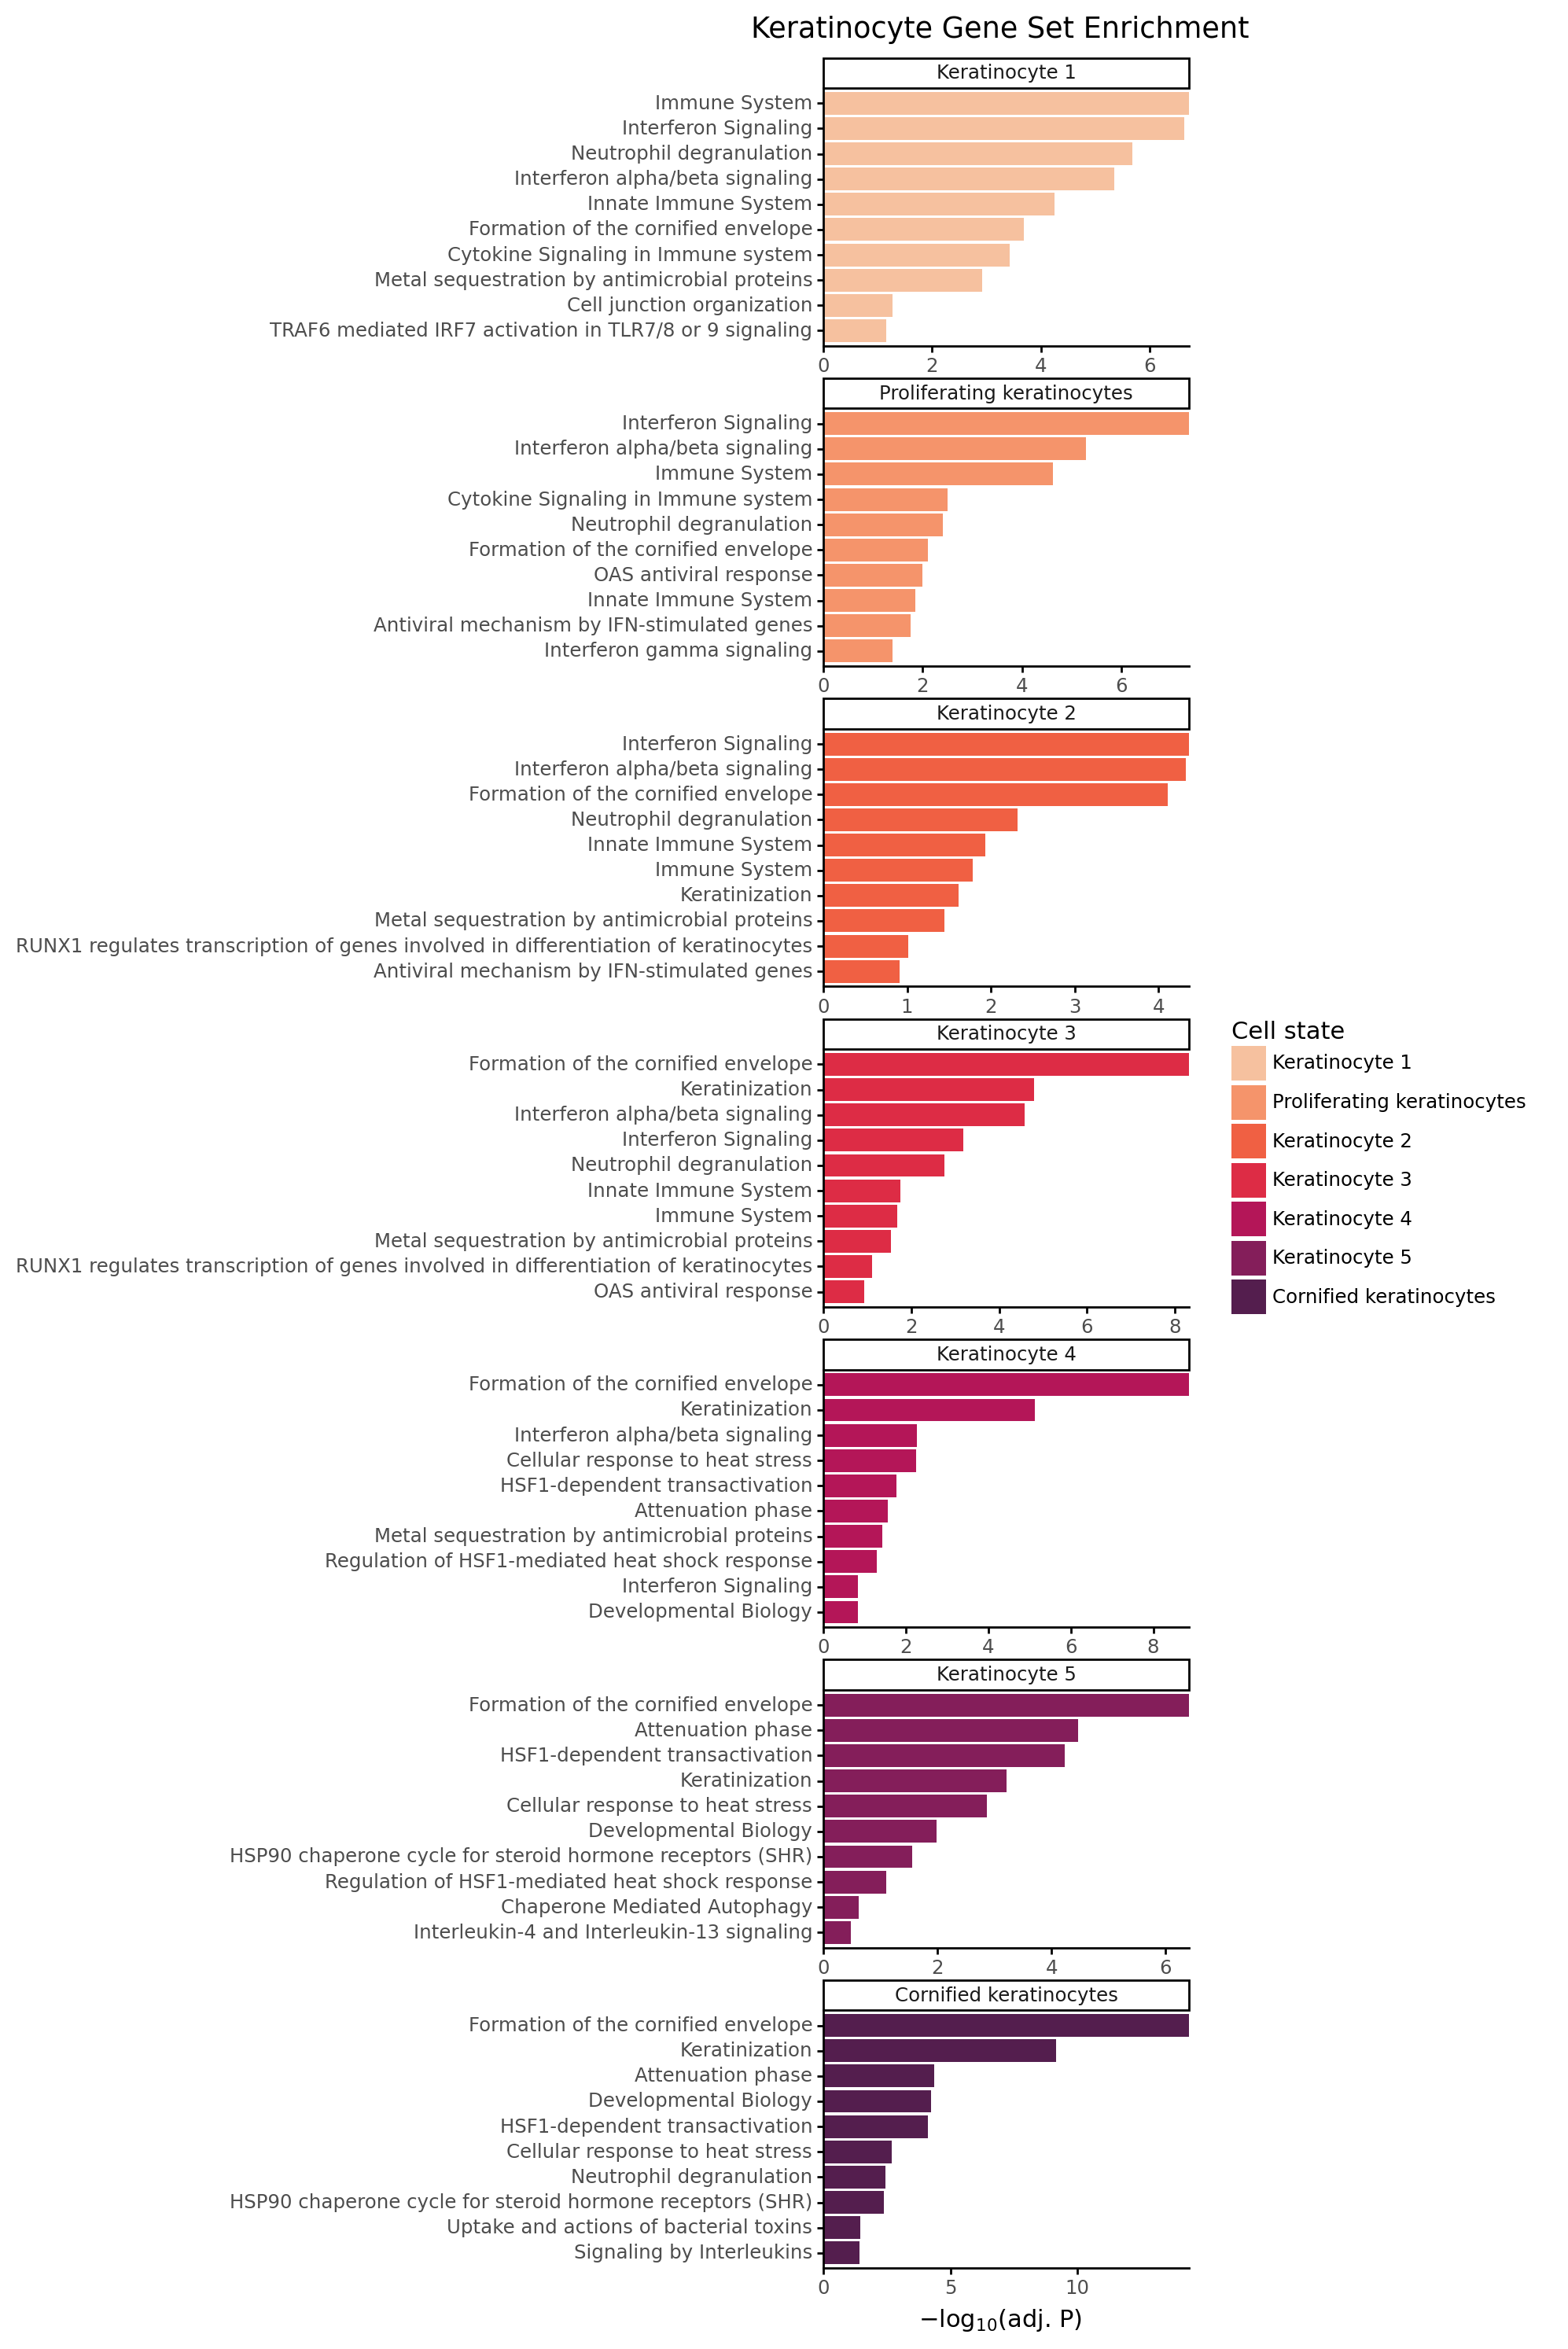

<ggplot: (8741946901459)>

In [626]:
from plotnine import *

import matplotlib.patheffects as path_effects
pe = [path_effects.Stroke(linewidth=1.5, foreground='white'), path_effects.Normal()]

en_df = go_df.copy()
en_df['intersections_append'] = [', '.join(x[:5]) for x in en_df.intersections]
en_df = en_df.merge((en_df.groupby('query').neglog10_pval.max()*0.01).reset_index().rename(columns={'neglog10_pval': 'textstart'}))
en_df['name_ctg'] = pd.Categorical(en_df['name_ctg'], categories=en_df['name_ctg'].cat.categories[::-1])
figsize = (3,18)

g = (
    ggplot(en_df, aes(x='name_ctg', y='neglog10_pval')) + 
    geom_bar(aes(fill='query'), stat='identity') + 
    #geom_hline(yintercept=1, size=0.1) +     
    #geom_text(aes(x='name_ctg', y='textstart', label='intersections_append'), size=6.5, fontweight='normal', color='black', ha='left', path_effects=pe)+ #, data=en_df[['name', 'neglog10_pval', 'tissue', 'intersections_append']].drop_duplicates())+ #, ) +
    coord_flip() + 
    scale_x_discrete(labels=lambda x: [x.split('|')[1] for x in list(x.keys())]) +
    scale_y_continuous(expand=(0,0,0,0)) +
    facet_wrap('query', scales='free', ncol=1) +
    scale_fill_manual(kera.uns['Cell type granular_colors'][:-1]) +
    labs(fill='Cell state') +
    theme_classic() +
    theme(figure_size=figsize, panel_spacing_y=0.2) +
    labs(y='$-\log_{10}$(adj. P)', x='', title='Keratinocyte Gene Set Enrichment')
)

display(g)

ggsave(g, 'figures/Figure2/barplot-keratinocyte-healthy-lesional-DE-GO.pdf')

## DPT correlation in healthy

In [486]:
kera_h = kera[kera.obs.disease_lesional == 'Healthy'].copy()
kera_h

AnnData object with n_obs × n_vars = 27651 × 18688
    obs: '10x_cell_calling', 'G2M_score', 'S_score', 'barcode_rank', 'chemistry_10x', 'disease_status', 'empty_drops_FDR', 'ind_id', 'lesional', 'log10_n_genes', 'log10_n_umis', 'mito_cutoff_', 'mt_frac', 'n_counts', 'n_genes', 'n_umis', 'neg_log10_empty_drops_FDR', 'phase', 'predicted_cell_types', 'predicted_sex', 'raw', 'sample_name', 'scrublet', 'scrublet_score', 'sex', 'disease_lesional', 'batch', 'leiden', 'Cell type', 'Cell type granular', 'ind_sample', 'channel', 'barcode', 'subject_id', 'global_disease_assessment', 'ad_family_history', 'sex_clinical', 'childbearing_potential', 'ethnicity_race', 'smoking', 'asthma', 'other_condition', 'systemic_corticosteroids', 'topical_corticosteroids', 'dupilumab', 'dupilumab_indication', 'dupilumab_other_indication', 'location', 'side', 'Disease score (MADAD Immune)', 'Disease score (MADAD Full)', 'Disease score (MADAD Union)', 'Cell type new cornified', 'dpt_pseudotime'
    var: 'highly_var

In [487]:
%%time

spe = sp.stats.spearmanr(kera_h[:, deles.gene].X.A, kera_h.obs.dpt_pseudotime)[0][-1][:-1]
deles['dpt_correlation'] = spe

CPU times: user 19.5 s, sys: 12.7 s, total: 32.2 s
Wall time: 7.14 s


In [488]:
%%time

spe = sp.stats.spearmanr(kera_h[:, denonles.gene].X.A, kera_h.obs.dpt_pseudotime)[0][-1][:-1]
denonles['dpt_correlation'] = spe

CPU times: user 585 ms, sys: 53.2 ms, total: 639 ms
Wall time: 634 ms


In [489]:
deles

,gene,pval,qval,log2fc,mean,coef,coef_sd,celltype,condition,significance,celltype_granular,spring_score,healthy_alpha,lesional_alpha,nonlesional_alpha,significant,dpt_correlation
0,ACSL4,0.000000e+00,0.000000e+00,1.228533,0.092204,1.228533,0.064257,Keratinocytes,Lesional,***,Keratinocyte 1,0.358528,0.025779,0.117153,0.085504,True,-0.078836
1,ACTN1,0.000000e+00,0.000000e+00,1.739591,0.319333,1.739591,0.046035,Keratinocytes,Lesional,***,Keratinocyte 1,0.364252,0.047497,0.282953,0.153101,True,-0.049502
2,ACTR1A,0.000000e+00,0.000000e+00,1.103821,0.133597,1.103821,0.053981,Keratinocytes,Lesional,***,Keratinocyte 1,0.025738,0.035314,0.166134,0.065284,True,0.098877
3,ADAR,0.000000e+00,0.000000e+00,1.199840,0.206813,1.199840,0.043119,Keratinocytes,Lesional,***,Keratinocyte 1,0.126669,0.055708,0.237838,0.129883,True,0.091199
4,ADORA2B,0.000000e+00,0.000000e+00,1.159267,0.081153,1.159267,0.066776,Keratinocytes,Lesional,***,Keratinocyte 1,0.152081,0.024455,0.102759,0.097413,True,-0.022087
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2075,WFDC12,0.000000e+00,0.000000e+00,1.641999,31.651877,1.641999,0.166912,Cornified keratinocytes,Lesional,***,Cornified keratinocytes,0.384243,0.506849,0.808219,0.760479,True,0.077726
2076,ZCCHC6,1.844588e-06,1.643535e-05,1.175060,0.395904,1.175060,0.246357,Cornified keratinocytes,Lesional,***,Cornified keratinocytes,0.178754,0.150685,0.308219,0.335329,True,0.102624
2077,ZFP36,4.093392e-12,9.086625e-11,1.267260,2.505119,1.267260,0.182762,Cornified keratinocytes,Lesional,***,Cornified keratinocytes,0.082038,0.376712,0.609589,0.646707,True,0.009424
2078,ZFYVE1,8.731722e-03,3.022068e-02,-1.150052,0.156997,-1.150052,0.438552,Cornified keratinocytes,Lesional,*,Cornified keratinocytes,-0.224105,0.143836,0.082192,0.167665,True,0.017985


In [490]:
deles = deles[deles.dpt_correlation.abs()>.1]
denonles = denonles[denonles.dpt_correlation.abs()>.1]

In [491]:
deles.gene.nunique()

296

In [492]:
denonles.gene.nunique()

37

In [493]:
remove_up_genes = 'SH3PXD2A, GSDMA, CARD18, NCCRP1, METRNL, FAM25A, CST6, BPIFC, TMEM40, CYSRT1, TMPRSS13'.split(', ')

In [494]:
extra_up_genes = 'LCE3E, LCE3D, LCE3A, SPRR2G, SPRR2D, SPRR2E, SPRR2B, SPRR1B, SPRR2F, SPRR2A, PPL, DMKN, CALML5, KLK11, SERPINB13, S100A9, S100A7, CCL27, IFI27, IFI44, IFI44L, ISG15, OAS1, KRT16, KRT6A, KRT6B, IL36G, IL36RN, IL18, GSDMD, NLRP1, PYDC1'.split(', ')

In [495]:
extra_down_genes = 'LOR, FLG2, FLG, LCE5A, LCE1E, LCE1D, LCE4A, LCE1F, LCE6A, LCE2D, LCE1A, LCE2B, LCE1B, IL18, IL1F10, IL37, IL1R2, PSORS1C2, IL1A'.split(', ')

In [496]:
les_genes = list(set(deles.gene.tolist()))
nonles_genes = list(set(denonles.gene.tolist()))

les_up = list(set(deles[deles.log2fc>0].gene.tolist()))
les_down = list(set(deles[deles.log2fc<0].gene.tolist()))

nonles_up = list(set(denonles[denonles.log2fc>0].gene.tolist()))
nonles_down = list(set(denonles[denonles.log2fc<0].gene.tolist()))

In [497]:
les_up = list((set(les_up) | set(extra_up_genes)) - (set(les_down) | set(up_exclude) | set(remove_up_genes)))
les_down = list((set(les_down) | set(extra_down_genes)) - (set(les_up) | set(down_exclude)))
les_genes  = les_up + les_down

In [498]:
nonles_up = list(set(nonles_up) - set(nonles_down))
nonles_down = list(set(nonles_down) - set(nonles_up))
nonles_down  = nonles_up + nonles_down

In [499]:
len(les_genes), len(les_up), len(les_down),

(248, 152, 96)

In [500]:
len(nonles_genes), len(nonles_up), len(nonles_down)

(37, 15, 37)

In [501]:
il_genes = 'IL36G, IL36RN, IL1A, IL1B, IL37, IL1F10, IL18, GSDMA, GSDMD, NLRP10, NLRP1, AIM2, PYDC1, PYCARD, CARD18, CASP1, CASP14'.split(', ')

In [502]:
#env_genes = 'S100A9, S100A12, S100A8, S100A15, S100A6, S100A5, S100A4, S100A3, S100A2, S100A16, S100A14, S100A13, S100A1, S100A10, S100A11, THHL, THH, RPTN, HRNR, FLG, FLG2, CRNN, LCE5A, CRCT1, LCE3E, LCE3D, LCE3B, LCE3A, LCE2D, LCE2C, LCE2B, LCE2A, LCE4A, LCE1F, LEP7, LCE1E, LCE1D, LCE1B, LCE1A, LCE6A, IVL, SPRR4, SPRR1A, SPRR3, SPRR1B, SPRR2D, SPRR2A, SPRR2B, SPRR2F, SPRR2C, SPRR2G, LOR, LELP1, PEP9'.split(', ')

## Split datasets

In [503]:
kera_h = kera[kera.obs.disease_lesional == 'Healthy', kera.var_names.isin(les_genes + nonles_genes + il_genes)].copy()
kera_nl = kera[kera.obs.disease_lesional == 'Non-lesional', kera.var_names.isin(les_genes + nonles_genes + il_genes)].copy()
kera_l = kera[kera.obs.disease_lesional == 'Lesional', kera.var_names.isin(les_genes + nonles_genes + il_genes)].copy()

## Subsample states

In [504]:
min_cell = 100 #kera_h.obs['Cell type granular'].value_counts().min()
print(min_cell)

l = []

for x in kera_h.obs['Cell type granular'].cat.categories:
    if kera_h.obs['Cell type granular'].value_counts().loc[x] >= min_cell:
        temp_ad = sc.pp.subsample(kera_h[kera_h.obs['Cell type granular'] == x].copy(), copy=True, n_obs=min_cell, random_state=100)
    else:
        temp_ad = kera_h[kera_h.obs['Cell type granular'] == x].copy()
    
    l.append(temp_ad)
        
kera_h = sc.concat(l)
kera_h._sanitize()
kera_h.obs['Cell type granular'].cat.reorder_categories(kera.obs['Cell type granular'].cat.categories, inplace=True)
kera_h.uns['Cell type granular_colors'] = kera.uns['Cell type granular_colors']

100


... storing 'chemistry_10x' as categorical
... storing 'ind_id' as categorical
... storing 'predicted_cell_types' as categorical
... storing 'sample_name' as categorical
... storing 'leiden' as categorical
... storing 'Cell type' as categorical
... storing 'Cell type granular' as categorical
... storing 'ind_sample' as categorical
... storing 'channel' as categorical
... storing 'barcode' as categorical
... storing 'subject_id' as categorical
... storing 'Cell type new cornified' as categorical


In [505]:
min_cell = 100 #kera_h.obs['Cell type granular'].value_counts().min()
print(min_cell)

l = []

for x in kera_nl.obs['Cell type granular'].cat.categories:
    if kera_nl.obs['Cell type granular'].value_counts().loc[x] >= min_cell:
        temp_ad = sc.pp.subsample(kera_nl[kera_nl.obs['Cell type granular'] == x].copy(), copy=True, n_obs=min_cell, random_state=100)
    else:
        temp_ad = kera_nl[kera_nl.obs['Cell type granular'] == x].copy()
    
    l.append(temp_ad)
        
kera_nl = sc.concat(l)
kera_nl._sanitize()
kera_nl.obs['Cell type granular'].cat.reorder_categories(kera.obs['Cell type granular'].cat.categories, inplace=True)
kera_nl.uns['Cell type granular_colors'] = kera.uns['Cell type granular_colors']

100


... storing '10x_cell_calling' as categorical
... storing 'ind_id' as categorical
... storing 'predicted_cell_types' as categorical
... storing 'sample_name' as categorical
... storing 'leiden' as categorical
... storing 'Cell type' as categorical
... storing 'Cell type granular' as categorical
... storing 'ind_sample' as categorical
... storing 'channel' as categorical
... storing 'barcode' as categorical
... storing 'subject_id' as categorical
... storing 'global_disease_assessment' as categorical
... storing 'ad_family_history' as categorical
... storing 'ethnicity_race' as categorical
... storing 'smoking' as categorical
... storing 'asthma' as categorical
... storing 'systemic_corticosteroids' as categorical
... storing 'topical_corticosteroids' as categorical
... storing 'dupilumab' as categorical
... storing 'dupilumab_indication' as categorical
... storing 'location' as categorical
... storing 'side' as categorical
... storing 'Cell type new cornified' as categorical


In [506]:
min_cell = 100 #kera_h.obs['Cell type granular'].value_counts().min()
print(min_cell)

l = []

for x in kera_l.obs['Cell type granular'].cat.categories:
    if kera_l.obs['Cell type granular'].value_counts().loc[x] >= min_cell:
        temp_ad = sc.pp.subsample(kera_l[kera_l.obs['Cell type granular'] == x].copy(), copy=True, n_obs=min_cell, random_state=100)
    else:
        temp_ad = kera_l[kera_l.obs['Cell type granular'] == x].copy()
    
    l.append(temp_ad)
        
kera_l = sc.concat(l)
kera_l._sanitize()
kera_l.obs['Cell type granular'].cat.reorder_categories(kera.obs['Cell type granular'].cat.categories, inplace=True)
kera_l.uns['Cell type granular_colors'] = kera.uns['Cell type granular_colors']

100


... storing '10x_cell_calling' as categorical
... storing 'chemistry_10x' as categorical
... storing 'ind_id' as categorical
... storing 'phase' as categorical
... storing 'predicted_cell_types' as categorical
... storing 'sample_name' as categorical
... storing 'leiden' as categorical
... storing 'Cell type' as categorical
... storing 'Cell type granular' as categorical
... storing 'ind_sample' as categorical
... storing 'channel' as categorical
... storing 'subject_id' as categorical
... storing 'global_disease_assessment' as categorical
... storing 'ad_family_history' as categorical
... storing 'ethnicity_race' as categorical
... storing 'smoking' as categorical
... storing 'asthma' as categorical
... storing 'systemic_corticosteroids' as categorical
... storing 'topical_corticosteroids' as categorical
... storing 'dupilumab' as categorical
... storing 'dupilumab_indication' as categorical
... storing 'location' as categorical
... storing 'side' as categorical
... storing 'Cell type

In [507]:
kera_h

AnnData object with n_obs × n_vars = 737 × 271
    obs: '10x_cell_calling', 'G2M_score', 'S_score', 'barcode_rank', 'chemistry_10x', 'disease_status', 'empty_drops_FDR', 'ind_id', 'lesional', 'log10_n_genes', 'log10_n_umis', 'mito_cutoff_', 'mt_frac', 'n_counts', 'n_genes', 'n_umis', 'neg_log10_empty_drops_FDR', 'phase', 'predicted_cell_types', 'predicted_sex', 'raw', 'sample_name', 'scrublet', 'scrublet_score', 'sex', 'disease_lesional', 'batch', 'leiden', 'Cell type', 'Cell type granular', 'ind_sample', 'channel', 'barcode', 'subject_id', 'global_disease_assessment', 'ad_family_history', 'sex_clinical', 'childbearing_potential', 'ethnicity_race', 'smoking', 'asthma', 'other_condition', 'systemic_corticosteroids', 'topical_corticosteroids', 'dupilumab', 'dupilumab_indication', 'dupilumab_other_indication', 'location', 'side', 'Disease score (MADAD Immune)', 'Disease score (MADAD Full)', 'Disease score (MADAD Union)', 'Cell type new cornified', 'dpt_pseudotime'
    uns: 'Cell type gran

In [508]:
kera_nl

AnnData object with n_obs × n_vars = 789 × 271
    obs: '10x_cell_calling', 'G2M_score', 'S_score', 'barcode_rank', 'chemistry_10x', 'disease_status', 'empty_drops_FDR', 'ind_id', 'lesional', 'log10_n_genes', 'log10_n_umis', 'mito_cutoff_', 'mt_frac', 'n_counts', 'n_genes', 'n_umis', 'neg_log10_empty_drops_FDR', 'phase', 'predicted_cell_types', 'predicted_sex', 'raw', 'sample_name', 'scrublet', 'scrublet_score', 'sex', 'disease_lesional', 'batch', 'leiden', 'Cell type', 'Cell type granular', 'ind_sample', 'channel', 'barcode', 'subject_id', 'global_disease_assessment', 'ad_family_history', 'sex_clinical', 'childbearing_potential', 'ethnicity_race', 'smoking', 'asthma', 'other_condition', 'systemic_corticosteroids', 'topical_corticosteroids', 'dupilumab', 'dupilumab_indication', 'dupilumab_other_indication', 'location', 'side', 'Disease score (MADAD Immune)', 'Disease score (MADAD Full)', 'Disease score (MADAD Union)', 'Cell type new cornified', 'dpt_pseudotime'
    uns: 'Cell type gran

In [509]:
kera_l

AnnData object with n_obs × n_vars = 710 × 271
    obs: '10x_cell_calling', 'G2M_score', 'S_score', 'barcode_rank', 'chemistry_10x', 'disease_status', 'empty_drops_FDR', 'ind_id', 'lesional', 'log10_n_genes', 'log10_n_umis', 'mito_cutoff_', 'mt_frac', 'n_counts', 'n_genes', 'n_umis', 'neg_log10_empty_drops_FDR', 'phase', 'predicted_cell_types', 'predicted_sex', 'raw', 'sample_name', 'scrublet', 'scrublet_score', 'sex', 'disease_lesional', 'batch', 'leiden', 'Cell type', 'Cell type granular', 'ind_sample', 'channel', 'barcode', 'subject_id', 'global_disease_assessment', 'ad_family_history', 'sex_clinical', 'childbearing_potential', 'ethnicity_race', 'smoking', 'asthma', 'other_condition', 'systemic_corticosteroids', 'topical_corticosteroids', 'dupilumab', 'dupilumab_indication', 'dupilumab_other_indication', 'location', 'side', 'Disease score (MADAD Immune)', 'Disease score (MADAD Full)', 'Disease score (MADAD Union)', 'Cell type new cornified', 'dpt_pseudotime'
    uns: 'Cell type gran

## Sort each by pseudotime

In [510]:
kera_h = kera_h[np.argsort(kera_h.obs.dpt_pseudotime)].copy()
kera_nl = kera_nl[np.argsort(kera_nl.obs.dpt_pseudotime)].copy()
kera_l = kera_l[np.argsort(kera_l.obs.dpt_pseudotime)].copy()

In [511]:
kera_h

AnnData object with n_obs × n_vars = 737 × 271
    obs: '10x_cell_calling', 'G2M_score', 'S_score', 'barcode_rank', 'chemistry_10x', 'disease_status', 'empty_drops_FDR', 'ind_id', 'lesional', 'log10_n_genes', 'log10_n_umis', 'mito_cutoff_', 'mt_frac', 'n_counts', 'n_genes', 'n_umis', 'neg_log10_empty_drops_FDR', 'phase', 'predicted_cell_types', 'predicted_sex', 'raw', 'sample_name', 'scrublet', 'scrublet_score', 'sex', 'disease_lesional', 'batch', 'leiden', 'Cell type', 'Cell type granular', 'ind_sample', 'channel', 'barcode', 'subject_id', 'global_disease_assessment', 'ad_family_history', 'sex_clinical', 'childbearing_potential', 'ethnicity_race', 'smoking', 'asthma', 'other_condition', 'systemic_corticosteroids', 'topical_corticosteroids', 'dupilumab', 'dupilumab_indication', 'dupilumab_other_indication', 'location', 'side', 'Disease score (MADAD Immune)', 'Disease score (MADAD Full)', 'Disease score (MADAD Union)', 'Cell type new cornified', 'dpt_pseudotime'
    uns: 'Cell type gran

## Smoothen each subset

In [512]:
smooth_level = 50

In [513]:
def smooth(mat, n_convolve=50):
    weights = np.ones(n_convolve) / n_convolve
    if sp.sparse.issparse(mat):
        mat = mat.A
    for idx in tqdm(range(mat.shape[1])):
        try:
            mat[:, idx] = np.convolve(mat[:, idx], weights, mode="same")
        except ValueError:
            pass  # e.g. all-zero counts or nans cannot be convolved
    return mat

In [514]:
kera_h.layers['smooth'] = smooth(kera_h.X, smooth_level)
kera_nl.layers['smooth'] = smooth(kera_nl.X, smooth_level)
kera_l.layers['smooth'] = smooth(kera_l.X, smooth_level)

  0%|          | 0/271 [00:00<?, ?it/s]

  0%|          | 0/271 [00:00<?, ?it/s]

  0%|          | 0/271 [00:00<?, ?it/s]

## Sort DEGs

In [515]:
gene_idx = np.argsort(np.argmax(kera_h.layers['smooth'], axis=0)).flatten()

In [516]:
kera_h = kera_h[:, gene_idx].copy()
kera_nl = kera_nl[:, gene_idx].copy()
kera_l = kera_l[:, gene_idx].copy()

## Normalize expression globally

In [517]:
kera_concat = sc.concat([kera_h, kera_nl, kera_l])

In [518]:
kera_concat.layers['smooth'] = kera_concat.layers['smooth'] / kera_concat.layers['smooth'].max(0)

In [519]:
kera_h = kera_concat[kera_concat.obs.disease_lesional == 'Healthy'].copy()
kera_nl = kera_concat[kera_concat.obs.disease_lesional == 'Non-lesional'].copy()
kera_l = kera_concat[kera_concat.obs.disease_lesional == 'Lesional'].copy()

In [520]:
kera_h.obs['Cell type granular'].cat.reorder_categories(kera.obs['Cell type granular'].cat.categories, inplace=True)
kera_h.uns['Cell type granular_colors'] = kera.uns['Cell type granular_colors']

kera_nl.obs['Cell type granular'].cat.reorder_categories(kera.obs['Cell type granular'].cat.categories, inplace=True)
kera_nl.uns['Cell type granular_colors'] = kera.uns['Cell type granular_colors']

kera_l.obs['Cell type granular'].cat.reorder_categories(kera.obs['Cell type granular'].cat.categories, inplace=True)
kera_l.uns['Cell type granular_colors'] = kera.uns['Cell type granular_colors']

## Plot Heatmaps

### up

In [464]:
final_up_genes = '''SLC38A5
TIMP1
SFRP1
S100A2
CCL2
ODC1
RRAS
KRT14
FXYD5
THBS2
ITGB4
IGFBP3
TGFB1
PRR7
MOXD1
FSCN1
SLC16A1
ITGA6
GOLGA7B
RARRES3
C1R
VSIG8
DAPK2
CCM2
ST5
DSC2
S100A6
KRT5
KRT16
CCND2
IFI44
S100A8
IFITM3
C12orf75
ARPC1B
PTGES
LY6D
GSDMD
ANO1
KRT6B
KRT6A
OAS1
IFI27
BDH1
FAM102A
PLCG2
PPL
MYH9
ICMT
ESRP1
PKP3
PERP
DSG1
SREBF2
KRT2
CDH1
CSTB
SREBF1
SPRR1B
RANGAP1
ATP6V1A
CYP4F22
AMMECR1
ATP10B
FAM129B
ZCCHC6
GARS
CALML3
PRSS3
MFSD5
LYNX1
SLURP1
C10orf99
PTK6
PLA2G4E
FABP5
IVL
SULT2B1
HMGCR
RASGRP1
SCNN1A
PLA2G4D
TMEM45B
KRT80
SORT1
CD24
SDR16C5
CMTM6
CASP14
TGM3
SQLE
ALDH3B2
CLIC3
CALML5
SMIM5
TMEM45A
EVL
SLC27A4
ELOVL1
IL36RN
ADGRG1
SERPINB13
EPHX3
OSBPL2
KRT17
CNFN
PYDC1
PLA2G3
PLA2G2F
PDZK1IP1
CHI3L1
MBOAT2
DUOX1
DUOXA1
MAP2
SH3GL1
ANO9
ELOVL4
SDR9C7
SPRR2D
SPRR2B
ACPP
LCE3D
CARD14
TJP1
ATP6V1C2
LCE3E
IL36G
SDCBP2
GM2A
SPRR2E
C2orf54
SPRR2G
CDSN
HAL
ALOX12B
ELOVL7
LCE3A
SPRR2F
SPRR2A
S100A9
S100A7'''.split()

saving figure to file figures/Figure2/scvelo_heatmap_pseudotime_keratinocyte_diffheatmap_upmarkers_01-healthy.pdf


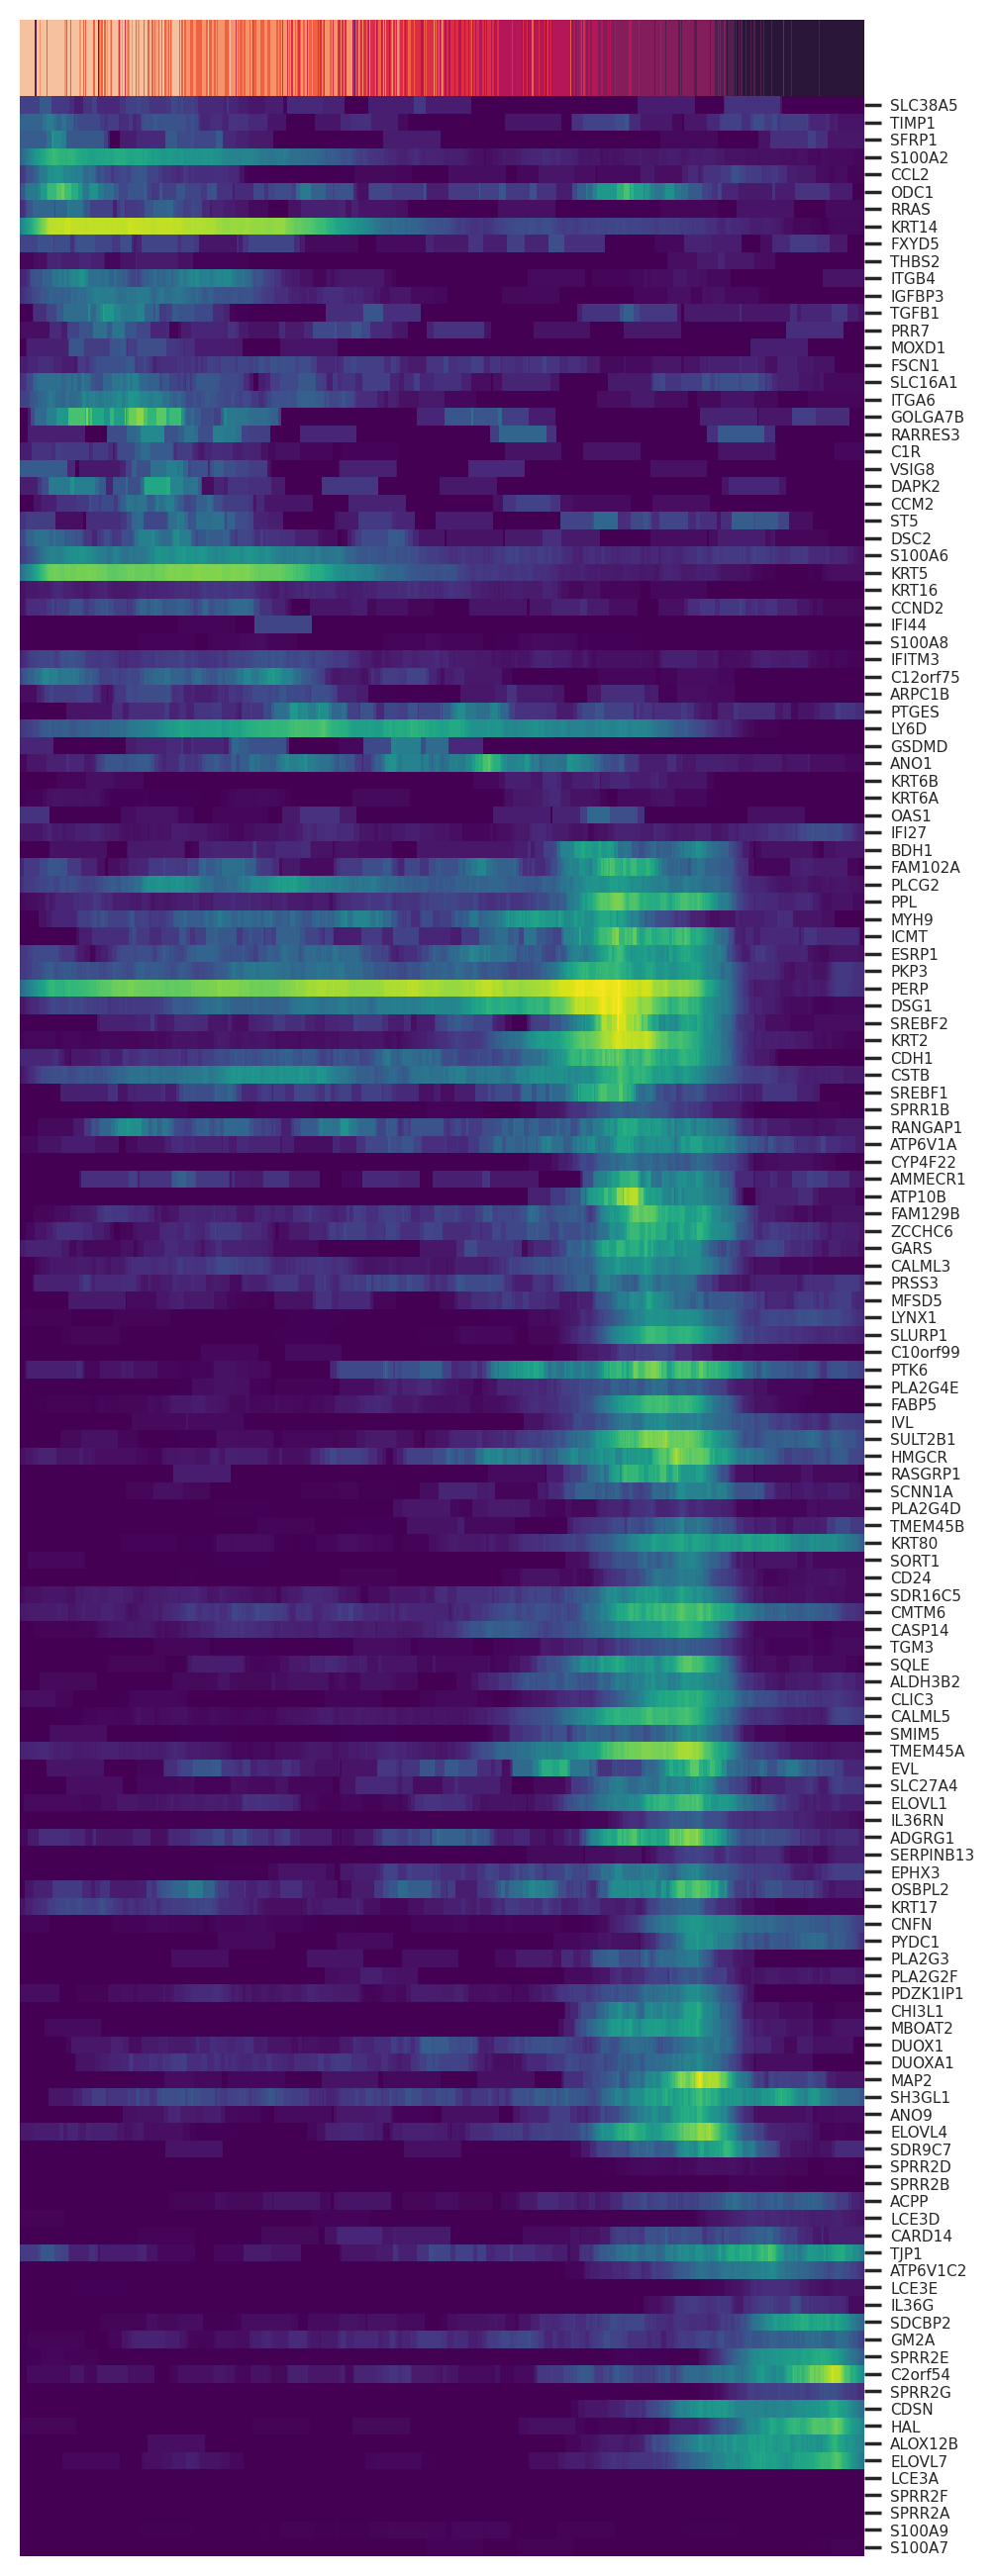

saving figure to file figures/Figure2/scvelo_heatmap_pseudotime_keratinocyte_diffheatmap_upmarkers_02-nonles.pdf


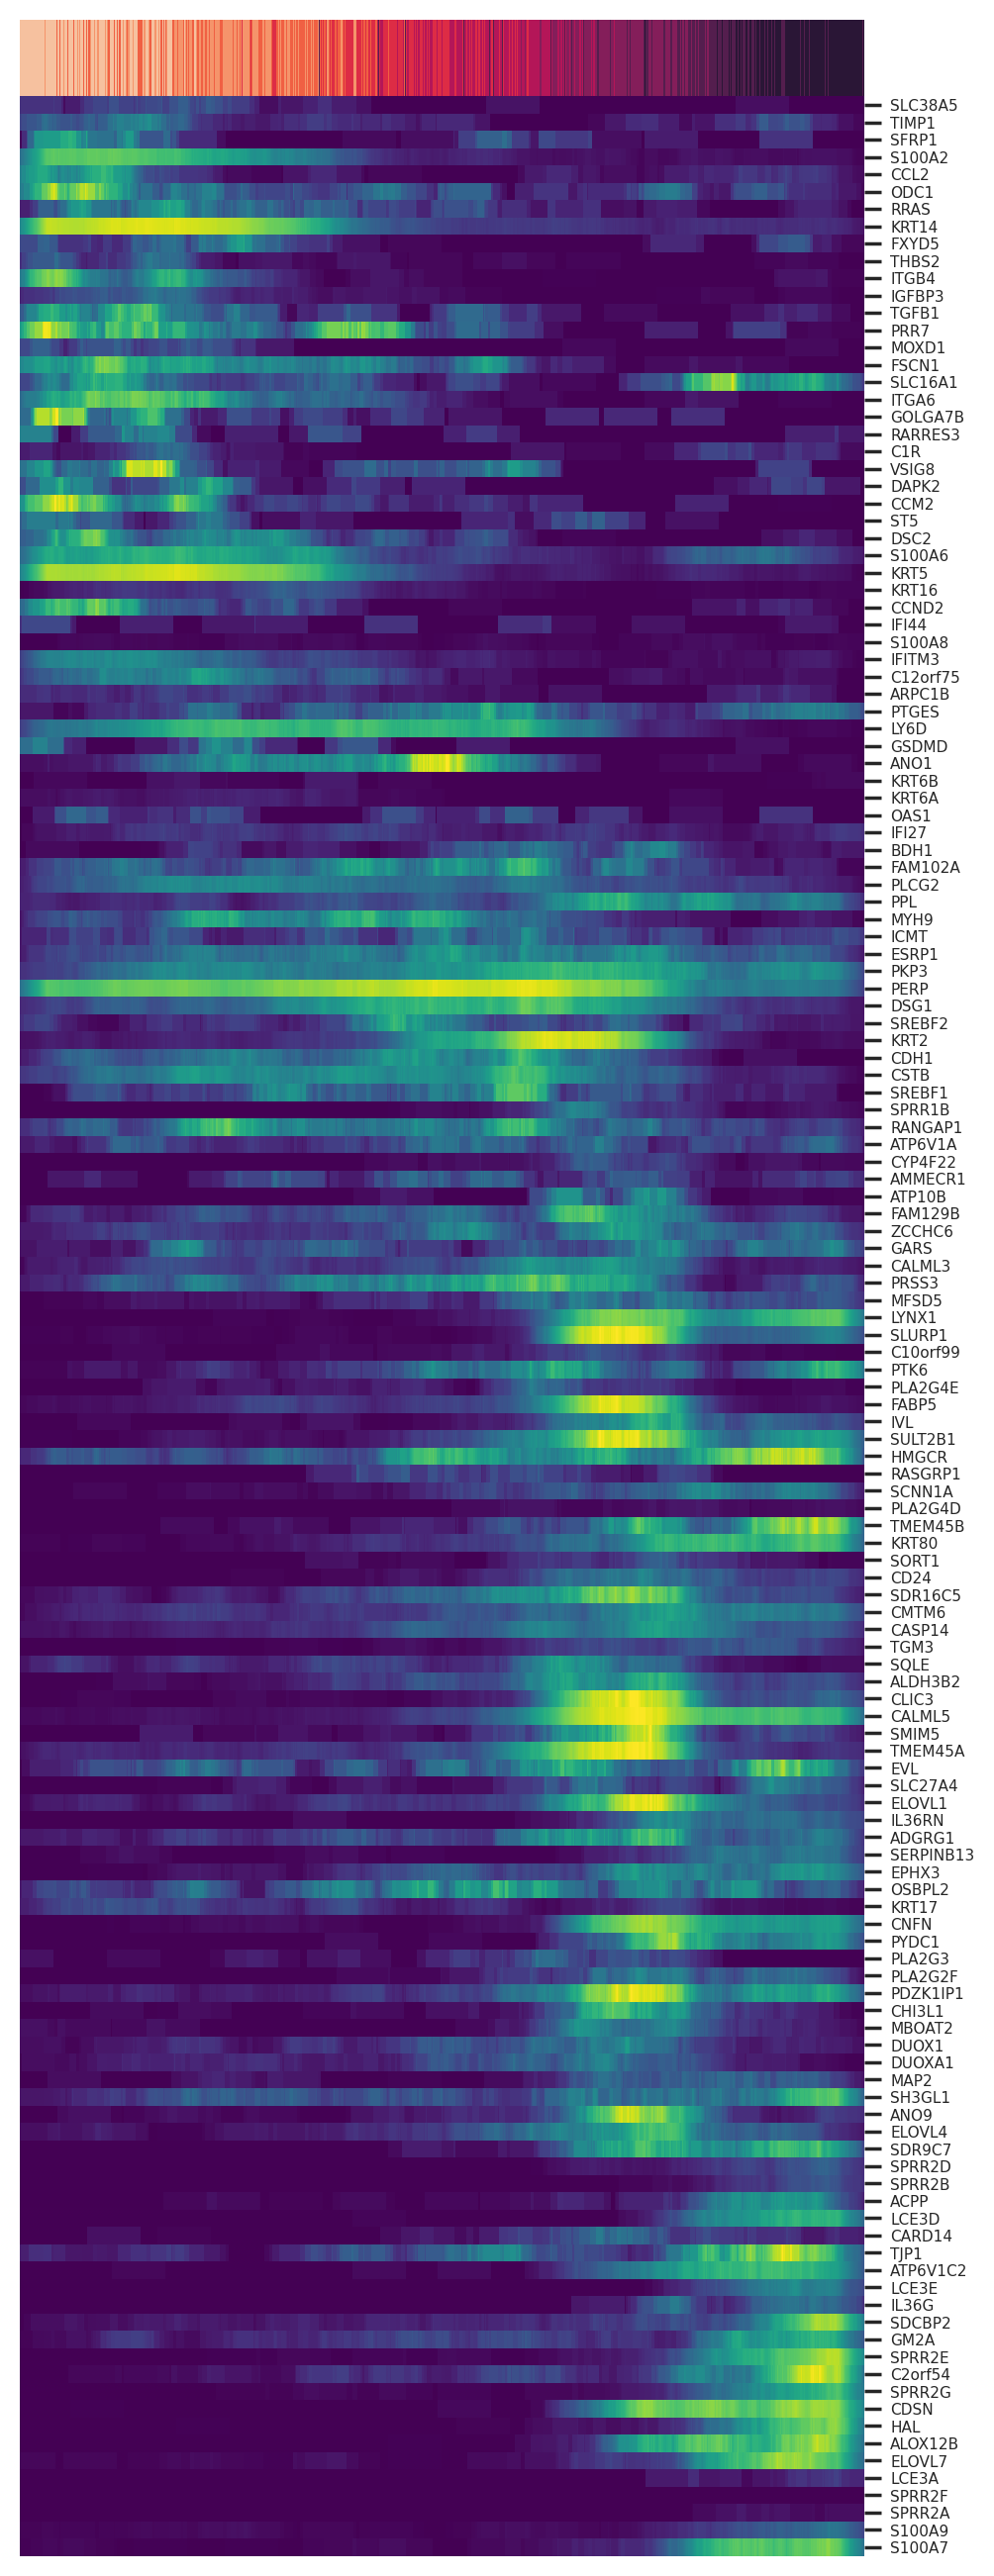

saving figure to file figures/Figure2/scvelo_heatmap_pseudotime_keratinocyte_diffheatmap_upmarkers_03-les.pdf


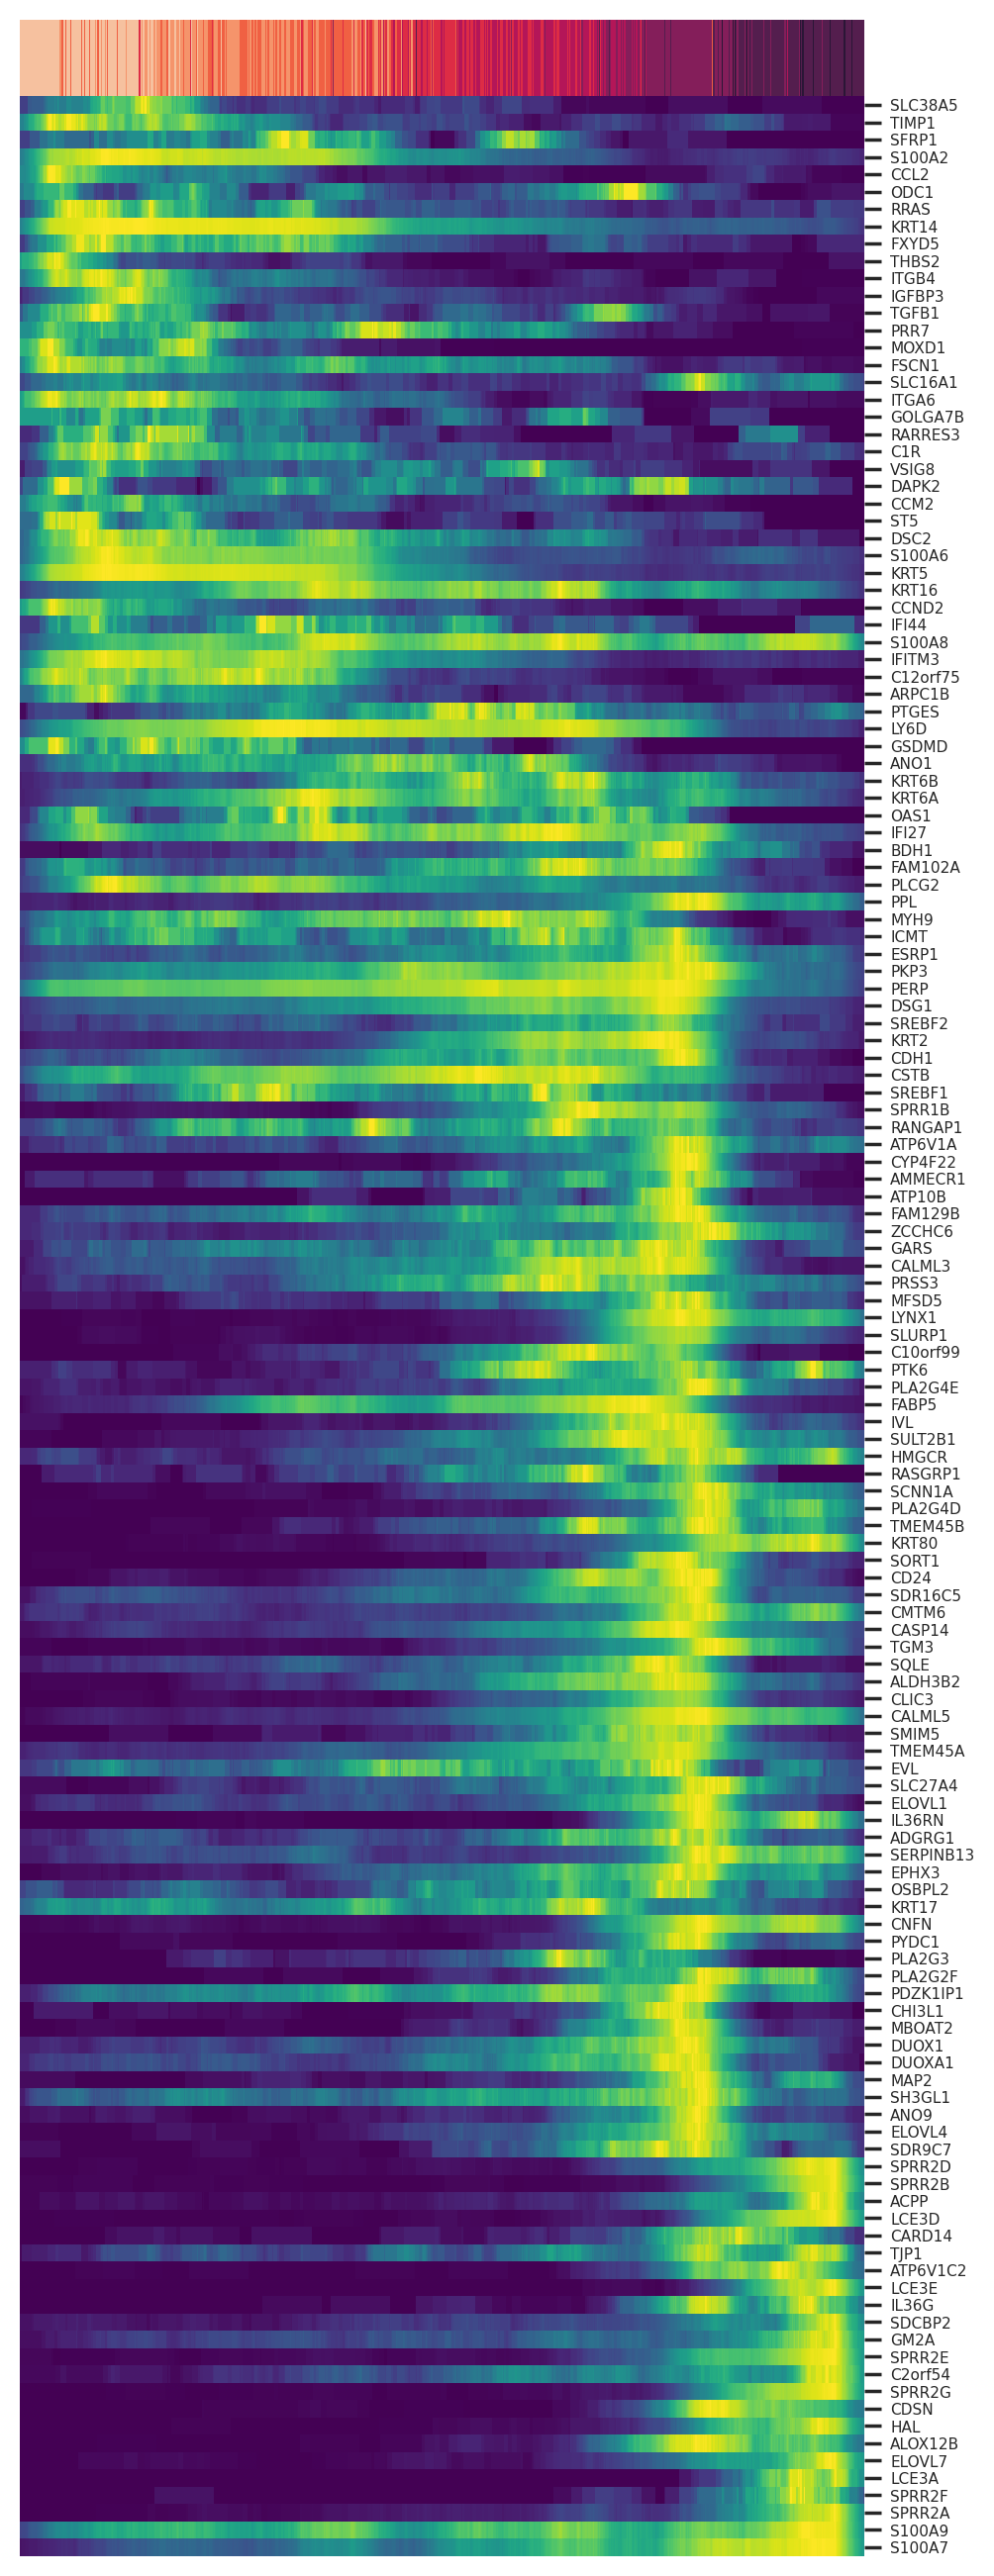

In [466]:
scv.pl.heatmap(
    kera_h,
    final_up_genes,
    layer='smooth',
    color_map='viridis',
    col_color='Cell type granular',
    figsize=(5,13),
    sort=False,
    yticklabels=True,
    n_convolve=None,
    sortby='dpt_pseudotime', 
    save='pseudotime_keratinocyte_diffheatmap_upmarkers_01-healthy.pdf', 
    colorbar=True,
    standard_scale=None,
    font_scale=0.5,
    vmax=1,
)

scv.pl.heatmap(
    kera_nl,
    final_up_genes,
    layer='smooth',
    color_map='viridis',
    col_color='Cell type granular',
    figsize=(5,13),
    sort=False,
    yticklabels=True,
    n_convolve=None,
    sortby='dpt_pseudotime', 
    save='pseudotime_keratinocyte_diffheatmap_upmarkers_02-nonles.pdf', 
    colorbar=True,
    standard_scale=None,
    font_scale=0.5,
    vmax=1,
)

scv.pl.heatmap(
    kera_l,
    final_up_genes,
    layer='smooth',
    color_map='viridis',
    col_color='Cell type granular',
    figsize=(5,13),
    sort=False,
    yticklabels=True,
    n_convolve=None,
    sortby='dpt_pseudotime', 
    save='pseudotime_keratinocyte_diffheatmap_upmarkers_03-les.pdf', 
    colorbar=True,
    standard_scale=None,
    font_scale=0.5,
    vmax=1,
)

### down

saving figure to file figures/Figure2/scvelo_heatmap_pseudotime_keratinocyte_diffheatmap_downmarkers_01-healthy.pdf


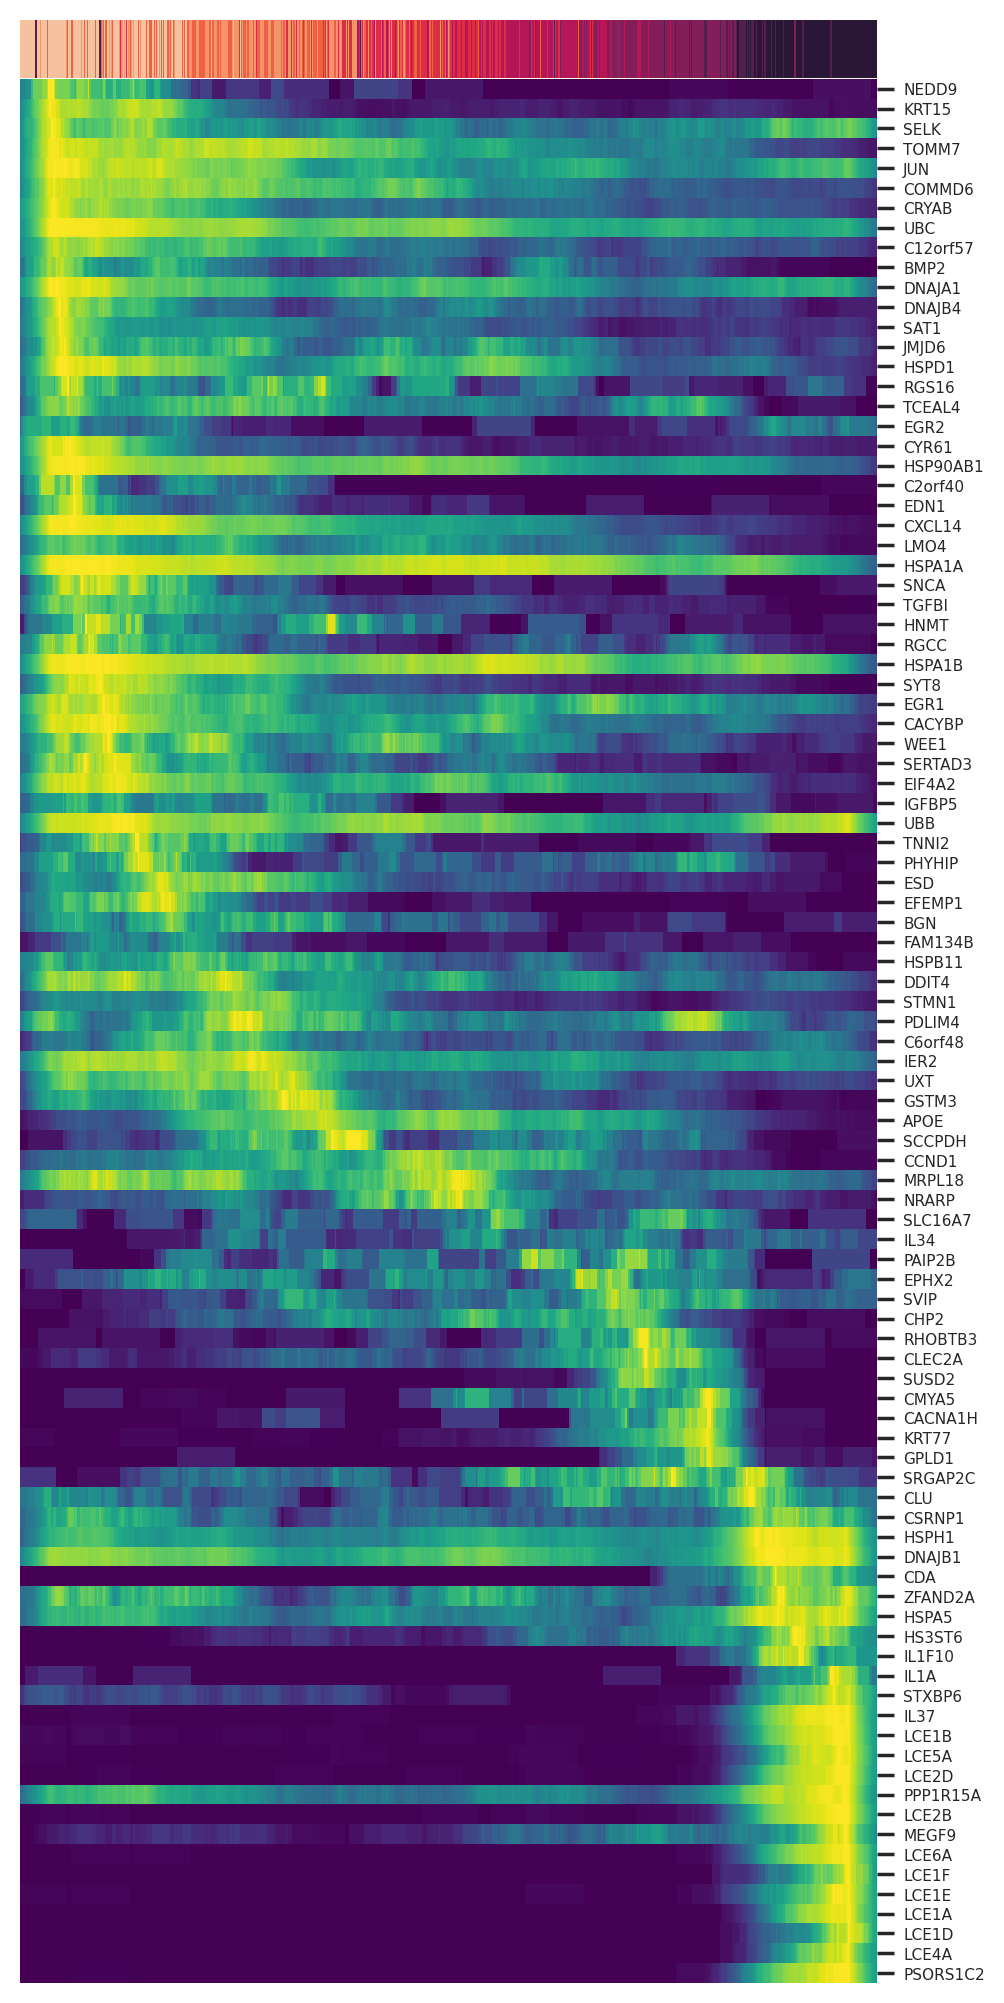

saving figure to file figures/Figure2/scvelo_heatmap_pseudotime_keratinocyte_diffheatmap_downmarkers_02-nonles.pdf


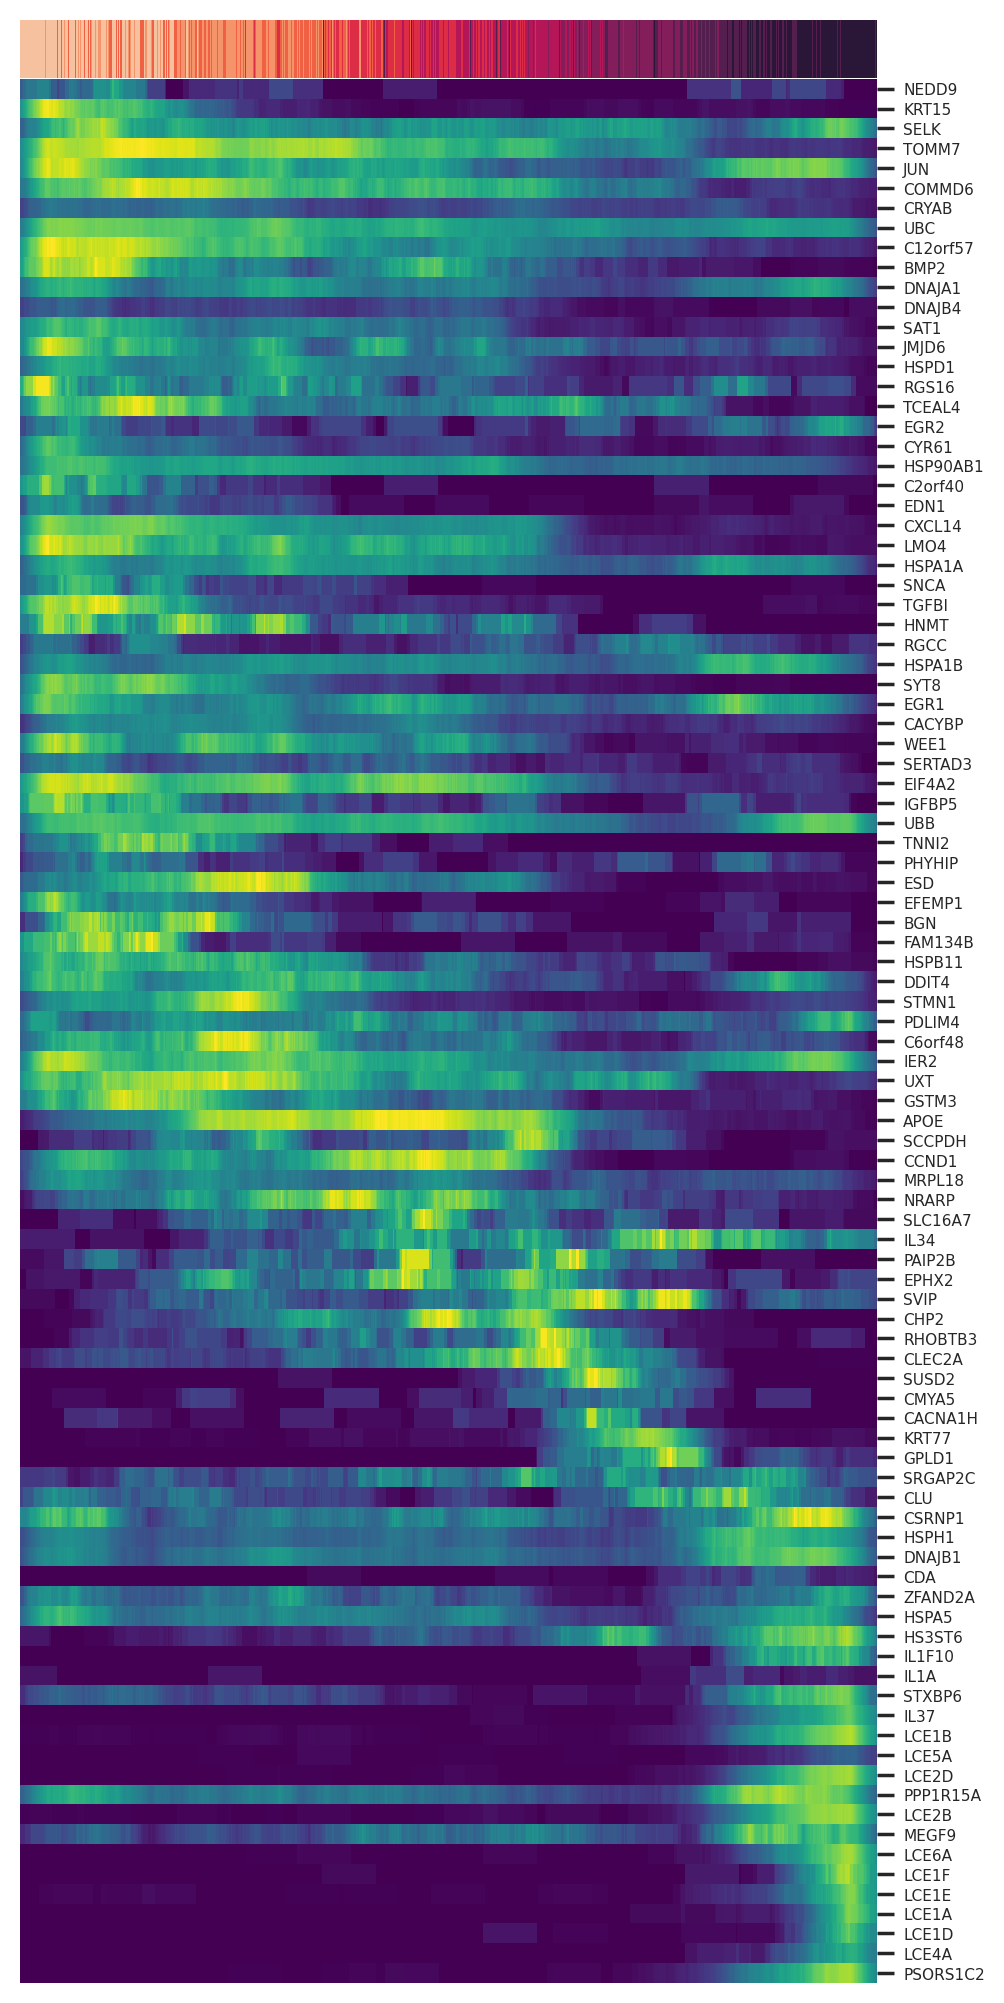

saving figure to file figures/Figure2/scvelo_heatmap_pseudotime_keratinocyte_diffheatmap_downmarkers_03-les.pdf


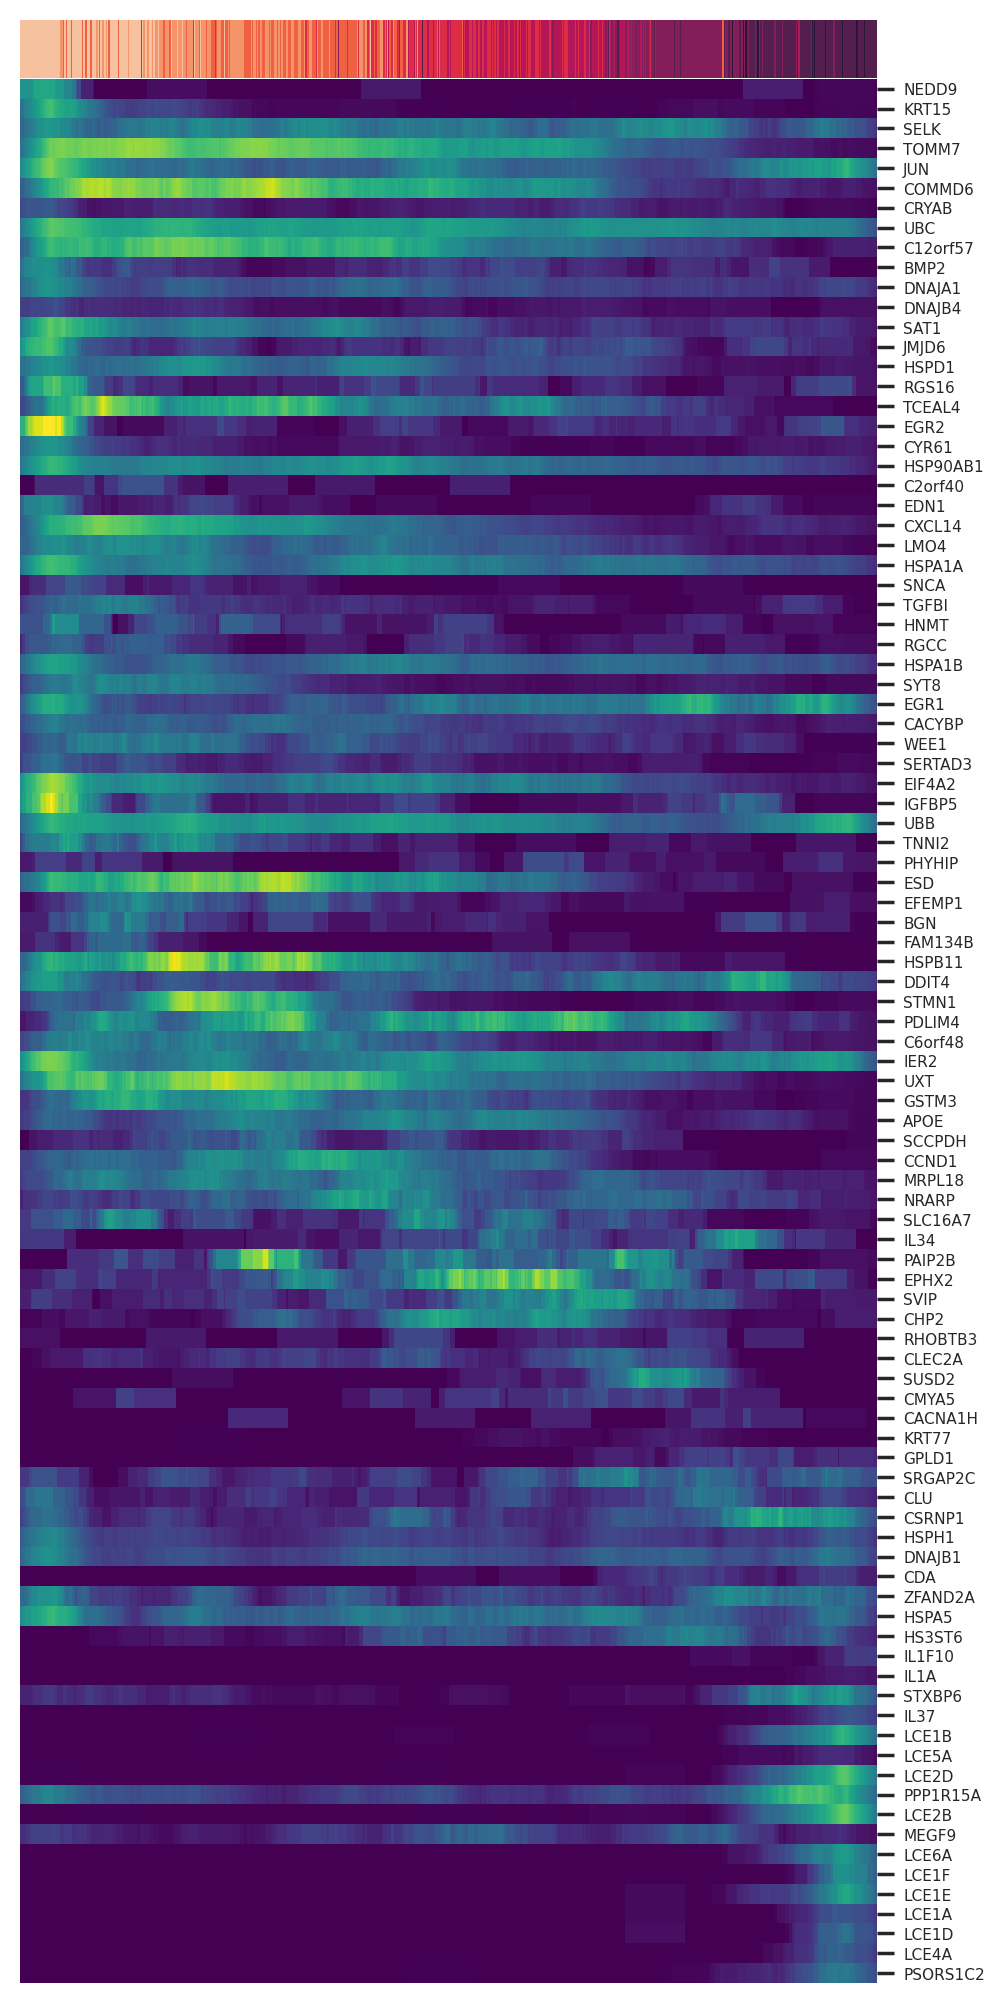

In [467]:
scv.pl.heatmap(
    kera_h,
    kera_h.var_names[kera_h.var_names.isin(les_down)],
    layer='smooth',
    color_map='viridis',
    col_color='Cell type granular',
    figsize=(5,10),
    sort=False,
    yticklabels=True,
    n_convolve=None,
    sortby='dpt_pseudotime', 
    save='pseudotime_keratinocyte_diffheatmap_downmarkers_01-healthy.pdf', 
    colorbar=True,
    standard_scale=None,
    font_scale=0.5,
    vmax=1,
)

scv.pl.heatmap(
    kera_nl,
    kera_nl.var_names[kera_nl.var_names.isin(les_down)],
    layer='smooth',
    color_map='viridis',
    col_color='Cell type granular',
    figsize=(5,10),
    sort=False,
    yticklabels=True,
    n_convolve=None,
    sortby='dpt_pseudotime', 
    save='pseudotime_keratinocyte_diffheatmap_downmarkers_02-nonles.pdf', 
    colorbar=True,
    standard_scale=None,
    font_scale=0.5,
    vmax=1,
)

scv.pl.heatmap(
    kera_l,
    kera_l.var_names[kera_l.var_names.isin(les_down)],
    layer='smooth',
    color_map='viridis',
    col_color='Cell type granular',
    figsize=(5,10),
    sort=False,
    yticklabels=True,
    n_convolve=None,
    sortby='dpt_pseudotime', 
    save='pseudotime_keratinocyte_diffheatmap_downmarkers_03-les.pdf', 
    colorbar=True,
    standard_scale=None,
    font_scale=0.5,
    vmax=1,
)

In [468]:
gene_list = kera_l.var_names[kera_l.var_names.isin(les_up)].tolist()

In [469]:
df = sc.queries.enrich(gene_list, gprofiler_kwargs={'all_results': False, 'sources': ['GO:BP', 'WP'], 'no_evidences': False})
df.name = [x[0].upper() + x[1:] for x in df.name]

In [470]:
pd.options.display.max_rows = 50

In [471]:
df.head(50)

,source,native,name,p_value,significant,description,term_size,query_size,intersection_size,effective_domain_size,precision,recall,query,parents,intersections,evidences
0,GO:BP,GO:0070268,Cornification,1.434138e-23,True,"""A type of programmed cell death that occurs i...",112,138,23,18117,0.166667,0.205357,query_1,"[GO:0012501, GO:0031424]","[SPRR2F, SPRR2A, KRT14, DSC2, KRT5, KRT16, KRT...","[[TAS], [TAS], [TAS], [TAS], [TAS], [TAS], [TA..."
1,GO:BP,GO:0043588,Skin development,3.013237e-23,True,"""The process whose specific outcome is the pro...",424,138,35,18117,0.253623,0.082547,query_1,[GO:0048513],"[LCE3A, SPRR2F, SPRR2A, KRT14, ITGB4, ITGA6, D...","[[IEA], [TAS, NAS, IEA], [TAS, NAS, IEA], [TAS..."
2,GO:BP,GO:0031424,Keratinization,1.313549e-21,True,"""The process in which the cytoplasm of the out...",224,138,27,18117,0.195652,0.120536,query_1,"[GO:0030216, GO:0032501]","[LCE3A, SPRR2F, SPRR2A, KRT14, DSC2, KRT5, KRT...","[[IEA], [TAS, IEA], [TAS, IEA], [TAS], [TAS], ..."
3,GO:BP,GO:0009913,Epidermal cell differentiation,1.419075e-20,True,"""The process in which a relatively unspecializ...",365,138,31,18117,0.224638,0.084932,query_1,"[GO:0008544, GO:0030855]","[LCE3A, SPRR2F, SPRR2A, KRT14, DSC2, KRT5, KRT...","[[IEA], [TAS, NAS, IEA], [TAS, NAS, IEA], [TAS..."
4,GO:BP,GO:0030216,Keratinocyte differentiation,1.758615e-20,True,"""The process in which a relatively unspecializ...",304,138,29,18117,0.210145,0.095395,query_1,"[GO:0009913, GO:0043588]","[LCE3A, SPRR2F, SPRR2A, KRT14, DSC2, KRT5, KRT...","[[IEA], [TAS, NAS, IEA], [TAS, NAS, IEA], [TAS..."
5,GO:BP,GO:0008544,Epidermis development,1.891954e-20,True,"""The process whose specific outcome is the pro...",475,138,34,18117,0.246377,0.071579,query_1,[GO:0009888],"[LCE3A, SPRR2F, SPRR2A, KRT14, DSC2, KRT5, KRT...","[[IEA], [TAS, NAS, IEA], [TAS, NAS, IEA], [TAS..."
6,GO:BP,GO:0030855,Epithelial cell differentiation,3.646890e-15,True,"""The process in which a relatively unspecializ...",798,138,36,18117,0.260870,0.045113,query_1,"[GO:0030154, GO:0060429]","[LCE3A, SPRR2F, SPRR2A, KRT14, TGFB1, CCM2, DS...","[[IEA], [TAS, NAS, IEA], [TAS, NAS, IEA], [TAS..."
7,GO:BP,GO:0012501,Programmed cell death,2.788799e-09,True,"""A process which begins when a cell receives a...",2143,138,48,18117,0.347826,0.022399,query_1,[GO:0008219],"[SPRR2F, SPRR2A, TIMP1, SGK1, SFRP1, CCL2, KRT...","[[TAS], [TAS], [IEA], [TAS, IEA], [IDA, IMP, I..."
8,GO:BP,GO:0060429,Epithelium development,4.236278e-09,True,"""The process whose specific outcome is the pro...",1325,138,37,18117,0.268116,0.027925,query_1,[GO:0009888],"[LCE3A, SPRR2F, SPRR2A, SFRP1, KRT14, TGFB1, C...","[[IEA], [TAS, NAS, IEA], [TAS, NAS, IEA], [IEA..."
9,GO:BP,GO:0009888,Tissue development,6.144776e-09,True,"""The process whose specific outcome is the pro...",2107,138,47,18117,0.340580,0.022307,query_1,[GO:0048856],"[LCE3A, SPRR2F, SPRR2A, TIMP1, SFRP1, KRT14, I...","[[IEA], [TAS, NAS, IEA], [TAS, NAS, IEA], [IEA..."


## IL-1 family genes

saving figure to file figures/Figure2/scvelo_heatmap_pseudotime_keratinocytes_IL1-01-healthy.pdf


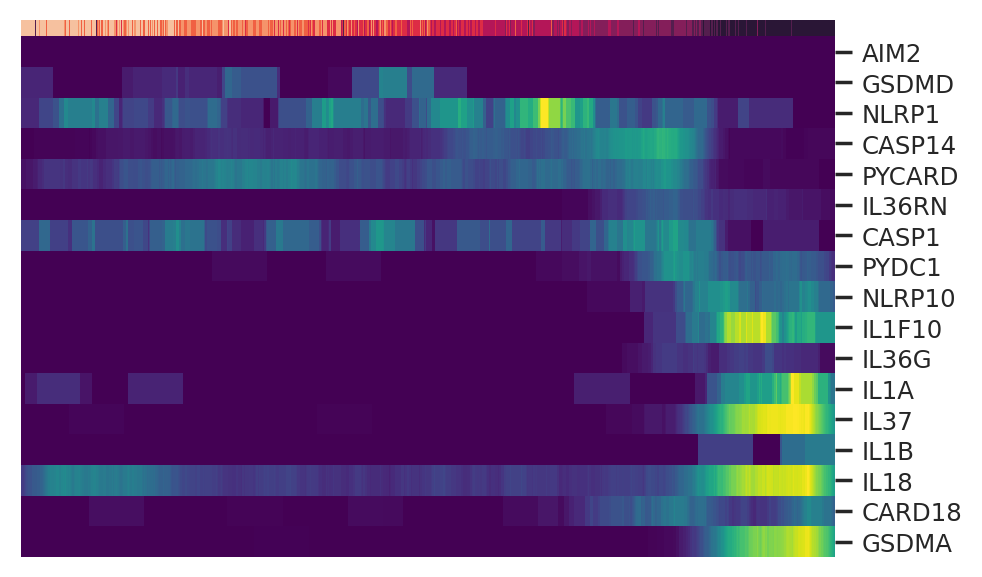

saving figure to file figures/Figure2/scvelo_heatmap_pseudotime_keratinocytes_IL1-02-nonles.pdf


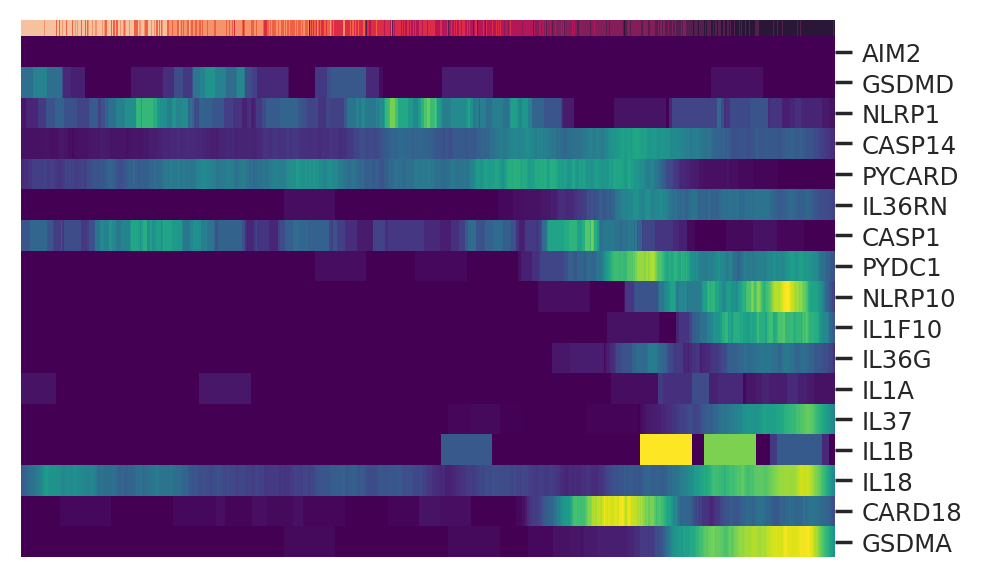

saving figure to file figures/Figure2/scvelo_heatmap_pseudotime_keratinocytes_IL1-03-les.pdf


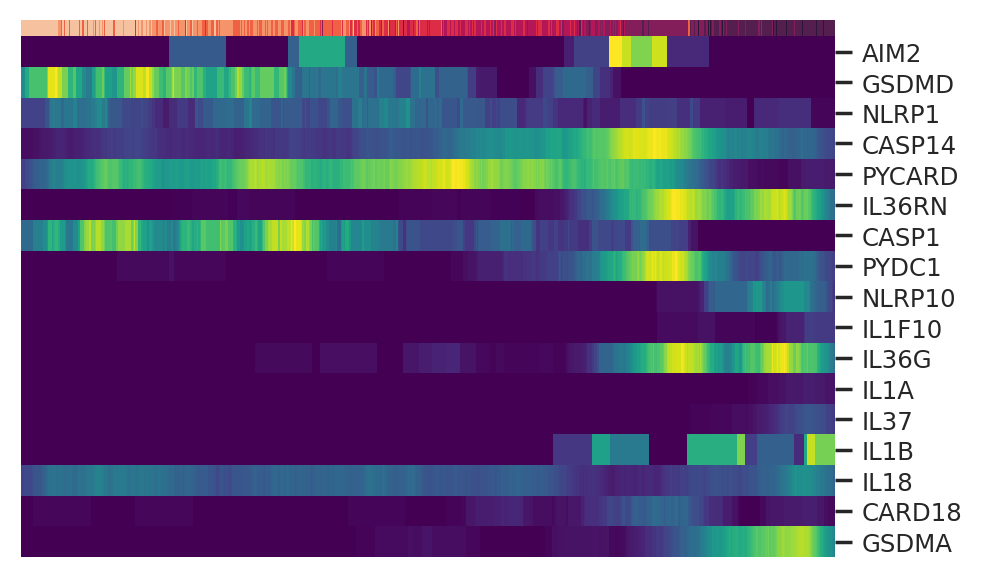

In [524]:
scv.pl.heatmap(
    kera_h,
    kera_h.var_names[kera_h.var_names.isin(il_genes)],
    layer='smooth',
    color_map='viridis',
    col_color='Cell type granular',
    figsize=(5,3),
    sort=False,
    yticklabels=True,
    n_convolve=None,
    sortby='dpt_pseudotime', 
    save='pseudotime_keratinocytes_IL1-01-healthy.pdf', 
    colorbar=True,
    standard_scale=None,
    font_scale=0.8,
    vmax=1,
)

scv.pl.heatmap(
    kera_nl,
    kera_nl.var_names[kera_nl.var_names.isin(il_genes)],
    layer='smooth',
    color_map='viridis',
    col_color='Cell type granular',
    figsize=(5,3),
    sort=False,
    yticklabels=True,
    n_convolve=None,
    sortby='dpt_pseudotime', 
    save='pseudotime_keratinocytes_IL1-02-nonles.pdf', 
    colorbar=True,
    standard_scale=None,
    font_scale=0.8,
    vmax=1,
)

scv.pl.heatmap(
    kera_l,
    kera_l.var_names[kera_l.var_names.isin(il_genes)],
    layer='smooth',
    color_map='viridis',
    col_color='Cell type granular',
    figsize=(5,3),
    sort=False,
    yticklabels=True,
    n_convolve=None,
    sortby='dpt_pseudotime', 
    save='pseudotime_keratinocytes_IL1-03-les.pdf', 
    colorbar=True,
    standard_scale=None,
    font_scale=0.8,
    vmax=1,
)